<br>
<font>
<div dir=ltr align=center>
<br>
<font color=#008566 size=6>
- Closed-form Approximations in Multi-Asset Market Making - <br>
<font color= #008566 size=6>
Backtest Implementation (BTC/IRT + USDT/IRT) <br>
<font color= #006CB8  size=5>
<!-- <br> -->
Mahdi Aghaei
<br>
https://sites.google.com/view/mahdiaghaei


<font color= #B1040E size=4>
<br>
Summer 2026

<!-- <br> -->

____

## Theoretical framework

For assets $i\in\{1,\ldots,d\}$, the reference-price dynamics are

$$
dS_t^i=\sigma_i\,dW_t^i,
$$

with covariance matrix

$$
\Sigma_{ij}=\rho_{ij}\sigma_i\sigma_j.
$$

The execution intensities are assumed symmetric and exponential:

$$
\Lambda^{i,b}(\delta)
=
\Lambda^{i,a}(\delta)
=
A_i e^{-k_i\delta}.
$$

For Model A, the objective is the expected CARA utility of terminal marked-to-market wealth:

$$
\sup_{\delta}
\mathbb E\left[
-\exp\left(
-\gamma
\left(
X_T+q_T^\top S_T
\right)
\right)
\right].
$$

For Model B, the objective is the expected terminal marked-to-market wealth minus the running quadratic inventory-risk penalty.

With symmetric exponential intensities, define

$$
C_i^\xi=
\begin{cases}
\left(1+\dfrac{\xi z_i}{k_i}\right)^{
-\left(1+\dfrac{k_i}{\xi z_i}\right)
},
& \xi>0,\\[6pt]
e^{-1},&\xi=0,
\end{cases}
$$

and

$$
D_+
=
\operatorname{diag}
\left(
2A_iC_i^\xi k_i z_i
\right)_{i=1}^d.
$$

The finite-horizon quadratic proxy is

$$
\check\theta(t,q)
=
-q^\top\mathcal A(t)q-C(t)
$$

in the symmetric case, because the linear term vanishes. Let

$$
A_b
=
\sqrt{\gamma}
\left(
D_+^{1/2}\Sigma D_+^{1/2}
\right)^{1/2}.
$$

Then

$$
\mathcal A(t)
=
\frac12
D_+^{-1/2}
A_b
\tanh\!\left(
A_b(T-t)
\right)
D_+^{-1/2}.
$$

For asset $i$, the finite-horizon proxy arguments are

$$
p_i^b
=
2q^\top\mathcal A(t)e_i
+
z_i e_i^\top\mathcal A(t)e_i,
$$

$$
p_i^a
=
-2q^\top\mathcal A(t)e_i
+
z_i e_i^\top\mathcal A(t)e_i.
$$

For Model A,

$$
\check\delta_i^b
=
p_i^b
+
\frac{1}{\gamma z_i}
\log\left(
1+\frac{\gamma z_i}{k_i}
\right),
$$

$$
\check\delta_i^a
=
p_i^a
+
\frac{1}{\gamma z_i}
\log\left(
1+\frac{\gamma z_i}{k_i}
\right).
$$

For Model B, the last term is replaced by $1/k_i$.

In the asymptotic regime,

$$
\Gamma
=
D_+^{-1/2}
\left(
D_+^{1/2}\Sigma D_+^{1/2}
\right)^{1/2}
D_+^{-1/2},
$$

and

$$
\mathcal A_\infty
=
\frac12\sqrt{\gamma}\Gamma.
$$

This makes each asset's skew depend on the **entire inventory vector**, not only on its own inventory.


## No-short inventory adaptation

The paper is naturally written with signed inventory. To stay consistent with the previous empirical implementation, this notebook keeps real inventory for each asset in

$$
0\le q_i^{\mathrm{real}}\le Q_i z_i.
$$

The neutral point is the middle of this interval. The signed inventory supplied to the closed-form approximation is therefore

$$
q_i
=
q_i^{\mathrm{real}}
-
\frac{Q_i z_i}{2}.
$$

Thus:

- $q_i=0$ means the real inventory is at half capacity;
- when real inventory reaches $Q_i z_i$, the bid for asset $i$ is disabled;
- when real inventory reaches $0$, the ask for asset $i$ is disabled;
- cash and inventory are updated with the actual observed trade volume;
- $z_i$ is estimated once from the median positive trade volume in the first causal lookback window.

This preserves the closed-form equations while imposing the empirical no-short constraint in the execution layer.


## Cell 1 — Libraries

Imports the numerical, data-processing, plotting, and typing utilities used throughout the notebook.


In [1]:
import math
from pathlib import Path
from typing import Any, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Cell 2 — Configuration

Defines dataset conventions, causal windows, calibration controls, policy candidates, quote mode, and evaluation settings.


In [2]:
EPS = 1e-12

ASSETS = ("BTC", "USDT")

FILE_CONFIG = {
    "BTC": {
        "orderbook_candidates": [
            "BTC_IRT_orderbook.csv",
            "BTC_IRT_orderbook(2).csv",
            "BTC_IRT_orderbook(2)(1).csv",
        ],
        "orderbook_pattern": "*BTC*IRT*orderbook*.csv",
        "trades_candidates": [
            "BTC_IRT_trades.csv",
            "BTC_IRT_trades(2).csv",
            "BTC_IRT_trades(2)(1).csv",
        ],
        "trades_pattern": "*BTC*IRT*trades*.csv",
        "direction_view": "maker",
        "strict_mid_filter": True,
        "absolute_excursion": False,
        "use_trade_reference_fallback": False,
    },
    "USDT": {
        "orderbook_candidates": [
            "USDT_IRT_orderbook(2).csv",
            "USDT_IRT_orderbook.csv",
        ],
        "orderbook_pattern": "*USDT*IRT*orderbook*.csv",
        "trades_candidates": [
            "USDT_IRT_trades(2).csv",
            "USDT_IRT_trades.csv",
        ],
        "trades_pattern": "*USDT*IRT*trades*.csv",
        "direction_view": "auto",
        "strict_mid_filter": False,
        "absolute_excursion": True,
        "use_trade_reference_fallback": True,
    },
}

LOOKBACK_SECONDS = 3600
MAX_ALIGNMENT_GAP_SECONDS = 20
MAX_CURRENT_ORDERBOOK_GAP_SECONDS = 20

TICK_ESTIMATION_ROWS = 1000
SIGMA_WINSOR_QUANTILE = 0.995
K_CENSOR_QUANTILE = 0.95

TRADE_REFERENCE_LOOKBACK_SECONDS = 300
TRADE_REFERENCE_MAX_TRADES_PER_SIDE = 20
VISIBLE_TO_TRADE_SPREAD_RATIO = 3.0

COVARIANCE_GRID_SECONDS = 10
COVARIANCE_MIN_POINTS = 20

MODEL_TYPE = "A"
QUOTE_MODE = "finite_horizon"

GAMMA = 1e-8
Q_STATES = {"BTC": 20, "USDT": 20}
HORIZON_SECONDS = 600.0

POLICY_TUNING_ENABLED = True
GAMMA_MULTIPLIERS = (0.5, 1.0, 2.0)
Q_CANDIDATES = (10, 20, 30)
HORIZON_CANDIDATES = (300.0, 600.0, 1200.0)
POLICY_TUNING_MAX_ROWS = 40
POLICY_TUNING_RECALIBRATE_SECONDS = 300.0
POLICY_INVENTORY_RISK_PENALTY = 0.75
POLICY_BOUNDARY_PENALTY = 2.0

RECALIBRATE_EVERY_SECONDS = 300.0
PASSIVE_CLIP = True

FINAL_MAX_ROWS = 1000
MARKOUT_HORIZON_SECONDS = 30

PARAMETER_STABILITY_POINTS = 60


## Cell 3 — Dataset loading and direction normalization

Loads the two order books and two trade files, constructs market prices, applies the fixed BTC maker-direction convention, causally resolves the USDT direction convention from the observed trade side relative to the order-book mid-price, and performs causal trade-to-book alignment.


In [3]:
LEVELS = range(1, 21)

BID_PRICE_COLS = [f"bid_price_{i}" for i in LEVELS]
ASK_PRICE_COLS = [f"ask_price_{i}" for i in LEVELS]
BID_VOLUME_COLS = [f"bid_volume_{i}" for i in LEVELS]
ASK_VOLUME_COLS = [f"ask_volume_{i}" for i in LEVELS]


def normalize_market_time(values: pd.Series) -> pd.Series:
    return (
        pd.to_datetime(values, errors="coerce", utc=True)
        .dt.tz_localize(None)
    )


def normalize_direction(value: Any) -> Optional[str]:
    direction = str(value).strip().lower()
    return direction if direction in {"buy", "sell"} else None


def resolve_file(candidates, fallback_pattern):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path

    matches = sorted(Path(".").glob(fallback_pattern))

    if not matches:
        raise FileNotFoundError(
            f"No file found among {candidates} or pattern {fallback_pattern}."
        )

    return matches[0]


def load_orderbook(asset: str) -> pd.DataFrame:
    config = FILE_CONFIG[asset]

    file_path = resolve_file(
        config["orderbook_candidates"],
        config["orderbook_pattern"],
    )

    raw = pd.read_csv(file_path)

    required = ["time"] + BID_PRICE_COLS + ASK_PRICE_COLS
    missing = [column for column in required if column not in raw.columns]

    if missing:
        raise ValueError(f"{asset}: missing order-book columns {missing}")

    raw["timestamp"] = normalize_market_time(raw["time"])

    numeric_columns = (
        BID_PRICE_COLS
        + ASK_PRICE_COLS
        + [
            column
            for column in BID_VOLUME_COLS + ASK_VOLUME_COLS
            if column in raw.columns
        ]
    )

    for column in numeric_columns:
        raw[column] = pd.to_numeric(raw[column], errors="coerce")

    raw[BID_PRICE_COLS] = raw[BID_PRICE_COLS].where(
        raw[BID_PRICE_COLS] > 0
    )

    raw[ASK_PRICE_COLS] = raw[ASK_PRICE_COLS].where(
        raw[ASK_PRICE_COLS] > 0
    )

    raw["best_bid"] = raw[BID_PRICE_COLS].max(axis=1, skipna=True)
    raw["best_ask"] = raw[ASK_PRICE_COLS].min(axis=1, skipna=True)
    raw["market_spread"] = raw["best_ask"] - raw["best_bid"]
    raw["mid"] = (raw["best_bid"] + raw["best_ask"]) / 2.0

    valid = (
        raw["timestamp"].notna()
        & np.isfinite(raw["best_bid"])
        & np.isfinite(raw["best_ask"])
        & np.isfinite(raw["mid"])
        & (raw["best_bid"] > 0)
        & (raw["best_ask"] > 0)
        & (raw["mid"] > 0)
        & (raw["best_bid"] < raw["best_ask"])
    )

    raw = raw.loc[valid].copy()

    if raw.empty:
        raise ValueError(f"{asset}: no valid order-book rows remain.")

    raw["asset"] = asset

    return (
        raw.sort_values("timestamp", kind="mergesort")
        .drop_duplicates(subset=["timestamp"], keep="last")
        .reset_index(drop=True)
    )


def load_trades(asset: str) -> pd.DataFrame:
    config = FILE_CONFIG[asset]

    file_path = resolve_file(
        config["trades_candidates"],
        config["trades_pattern"],
    )

    raw = pd.read_csv(file_path)

    required = ["trade_time", "direction", "price", "volume"]
    missing = [column for column in required if column not in raw.columns]

    if missing:
        raise ValueError(f"{asset}: missing trade columns {missing}")

    selected = [
        column
        for column in [
            "snapshot_time",
            "trade_time",
            "trade_id",
            "direction",
            "price",
            "volume",
        ]
        if column in raw.columns
    ]

    raw = raw[selected].copy()

    raw["trade_time"] = normalize_market_time(raw["trade_time"])

    if "snapshot_time" in raw.columns:
        raw["snapshot_time"] = normalize_market_time(raw["snapshot_time"])

    raw["price"] = pd.to_numeric(raw["price"], errors="coerce")
    raw["volume"] = pd.to_numeric(raw["volume"], errors="coerce")

    raw = raw.rename(columns={"direction": "direction_raw"})
    normalized = raw["direction_raw"].map(normalize_direction)

    if config["direction_view"] == "maker":
        raw["direction"] = normalized
    elif config["direction_view"] == "taker":
        raw["direction"] = normalized.map(
            {
                "sell": "buy",
                "buy": "sell",
            }
        )
    elif config["direction_view"] == "auto":
        raw["direction"] = normalized
    else:
        raise ValueError(
            f"{asset}: direction_view must be maker, taker, or auto."
        )

    valid = (
        raw["trade_time"].notna()
        & raw["direction"].notna()
        & np.isfinite(raw["price"])
        & np.isfinite(raw["volume"])
        & (raw["price"] > 0)
        & (raw["volume"] > 0)
    )

    raw = raw.loc[valid].copy()
    raw["asset"] = asset

    return (
        raw.sort_values("trade_time", kind="mergesort")
        .reset_index(drop=True)
    )


def causally_align_and_filter_trades(
    asset: str,
    trades: pd.DataFrame,
    orderbook: pd.DataFrame,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    config = FILE_CONFIG[asset]

    book = (
        orderbook[
            [
                "timestamp",
                "best_bid",
                "best_ask",
                "mid",
                "market_spread",
            ]
        ]
        .rename(
            columns={
                "timestamp": "book_time",
                "best_bid": "book_best_bid",
                "best_ask": "book_best_ask",
                "mid": "book_mid",
                "market_spread": "book_market_spread",
            }
        )
        .sort_values("book_time", kind="mergesort")
    )

    aligned = pd.merge_asof(
        trades.sort_values("trade_time", kind="mergesort"),
        book,
        left_on="trade_time",
        right_on="book_time",
        direction="backward",
        tolerance=pd.Timedelta(seconds=MAX_ALIGNMENT_GAP_SECONDS),
    ).dropna(
        subset=[
            "book_time",
            "book_best_bid",
            "book_best_ask",
            "book_mid",
        ]
    )

    if aligned.empty:
        raise ValueError(f"{asset}: no trades could be causally aligned.")

    maker_consistency = np.nan
    taker_consistency = np.nan
    raw_buy_offset = np.nan
    raw_sell_offset = np.nan
    resolved_direction_view = config["direction_view"]

    if config["direction_view"] == "auto":
        normalized_raw = aligned["direction_raw"].map(
            normalize_direction
        )

        maker_consistency = float(
            (
                (
                    normalized_raw.eq("buy")
                    & aligned["price"].le(aligned["book_mid"])
                )
                |
                (
                    normalized_raw.eq("sell")
                    & aligned["price"].ge(aligned["book_mid"])
                )
            ).mean()
        )

        taker_consistency = float(
            (
                (
                    normalized_raw.eq("sell")
                    & aligned["price"].le(aligned["book_mid"])
                )
                |
                (
                    normalized_raw.eq("buy")
                    & aligned["price"].ge(aligned["book_mid"])
                )
            ).mean()
        )

        raw_buy_offset = (
            aligned.loc[
                normalized_raw.eq("buy"),
                "price",
            ]
            - aligned.loc[
                normalized_raw.eq("buy"),
                "book_mid",
            ]
        ).median()

        raw_sell_offset = (
            aligned.loc[
                normalized_raw.eq("sell"),
                "price",
            ]
            - aligned.loc[
                normalized_raw.eq("sell"),
                "book_mid",
            ]
        ).median()

        if (
            np.isfinite(raw_buy_offset)
            and np.isfinite(raw_sell_offset)
        ):
            resolved_direction_view = (
                "taker"
                if raw_buy_offset > raw_sell_offset
                else "maker"
            )
        else:
            resolved_direction_view = (
                "taker"
                if taker_consistency > maker_consistency
                else "maker"
            )

        if resolved_direction_view == "taker":
            aligned["direction"] = normalized_raw.map(
                {
                    "sell": "buy",
                    "buy": "sell",
                }
            )
        else:
            aligned["direction"] = normalized_raw

    aligned["book_gap_seconds"] = (
        aligned["trade_time"] - aligned["book_time"]
    ).dt.total_seconds()

    if FILE_CONFIG[asset]["strict_mid_filter"]:
        keep = (
            (
                aligned["direction"].eq("buy")
                & aligned["price"].lt(aligned["book_mid"])
            )
            |
            (
                aligned["direction"].eq("sell")
                & aligned["price"].gt(aligned["book_mid"])
            )
        )
    else:
        keep = aligned["direction"].isin(["buy", "sell"])

    filtered = (
        aligned.loc[keep]
        .sort_values("trade_time", kind="mergesort")
        .reset_index(drop=True)
    )

    if filtered.empty:
        raise ValueError(f"{asset}: no maker-side trades remain.")

    diagnostics = {
        "asset": asset,
        "direction_view": FILE_CONFIG[asset]["direction_view"],
        "resolved_direction_view": resolved_direction_view,
        "maker_mapping_consistency": maker_consistency,
        "taker_mapping_consistency": taker_consistency,
        "raw_buy_median_price_minus_mid": float(raw_buy_offset),
        "raw_sell_median_price_minus_mid": float(raw_sell_offset),
        "n_input_trades": int(len(trades)),
        "n_causally_aligned_trades": int(len(aligned)),
        "n_kept_trades": int(len(filtered)),
        "n_removed_by_mid_filter": int(len(aligned) - len(filtered)),
        "n_maker_bid_trades": int(filtered["direction"].eq("buy").sum()),
        "n_maker_ask_trades": int(filtered["direction"].eq("sell").sum()),
        "median_book_gap_seconds": float(
            filtered["book_gap_seconds"].median()
        ),
    }

    return filtered, diagnostics


## Cell 4 — Load the four market-data files

Loads BTC/IRT and USDT/IRT data, reports the direction conventions and causal-filter diagnostics, and establishes the common backtest period.


In [4]:
orderbooks = {}
raw_trades = {}
trades = {}
trade_filter_diagnostics = {}

for asset in ASSETS:
    orderbooks[asset] = load_orderbook(asset)
    raw_trades[asset] = load_trades(asset)

    (
        trades[asset],
        trade_filter_diagnostics[asset],
    ) = causally_align_and_filter_trades(
        asset=asset,
        trades=raw_trades[asset],
        orderbook=orderbooks[asset],
    )

data_summary_rows = []

for asset in ASSETS:
    data_summary_rows.append(
        {
            "asset": asset,
            "direction_view_setting": FILE_CONFIG[asset]["direction_view"],
            "resolved_direction_view": trade_filter_diagnostics[asset][
                "resolved_direction_view"
            ],
            "orderbook_rows": len(orderbooks[asset]),
            "raw_trade_rows": len(raw_trades[asset]),
            "maker_side_trade_rows": len(trades[asset]),
            "maker_bid_rows": int(trades[asset]["direction"].eq("buy").sum()),
            "maker_ask_rows": int(trades[asset]["direction"].eq("sell").sum()),
            "orderbook_start": orderbooks[asset]["timestamp"].min(),
            "orderbook_end": orderbooks[asset]["timestamp"].max(),
            "trade_start": trades[asset]["trade_time"].min(),
            "trade_end": trades[asset]["trade_time"].max(),
        }
    )

data_summary = pd.DataFrame(data_summary_rows)
display(data_summary)

common_start = max(
    orderbooks[asset]["timestamp"].min()
    for asset in ASSETS
)

common_end = min(
    orderbooks[asset]["timestamp"].max()
    for asset in ASSETS
)

print("Common order-book period:", common_start, "->", common_end)

for asset in ASSETS:
    print()
    print(asset, trade_filter_diagnostics[asset])


,asset,direction_view_setting,resolved_direction_view,orderbook_rows,raw_trade_rows,maker_side_trade_rows,maker_bid_rows,maker_ask_rows,orderbook_start,orderbook_end,trade_start,trade_end
0,BTC,maker,maker,80862,22503,19539,10215,9324,2026-06-09 08:44:29,2026-06-18 22:09:29,2026-06-09 08:44:43,2026-06-18 22:07:19
1,USDT,auto,maker,80830,130517,129083,71028,58055,2026-06-09 08:44:29,2026-06-18 22:06:59,2026-06-09 08:44:53,2026-06-18 22:05:28


Common order-book period: 2026-06-09 08:44:29 -> 2026-06-18 22:06:59

BTC {'asset': 'BTC', 'direction_view': 'maker', 'resolved_direction_view': 'maker', 'maker_mapping_consistency': nan, 'taker_mapping_consistency': nan, 'raw_buy_median_price_minus_mid': nan, 'raw_sell_median_price_minus_mid': nan, 'n_input_trades': 22503, 'n_causally_aligned_trades': 22190, 'n_kept_trades': 19539, 'n_removed_by_mid_filter': 2651, 'n_maker_bid_trades': 10215, 'n_maker_ask_trades': 9324, 'median_book_gap_seconds': 5.0}

USDT {'asset': 'USDT', 'direction_view': 'auto', 'resolved_direction_view': 'maker', 'maker_mapping_consistency': 0.8886762780536555, 'taker_mapping_consistency': 0.1138182409767359, 'raw_buy_median_price_minus_mid': -28.0, 'raw_sell_median_price_minus_mid': 23.0, 'n_input_trades': 130517, 'n_causally_aligned_trades': 129083, 'n_kept_trades': 129083, 'n_removed_by_mid_filter': 0, 'n_maker_bid_trades': 71028, 'n_maker_ask_trades': 58055, 'median_book_gap_seconds': 4.0}


## Cell 5 — Estimate tick sizes and transaction sizes

Estimates a fixed tick size for each asset and a representative real transaction size $z_i$ from the first causal lookback window.


In [5]:
def estimate_tick_size(orderbook: pd.DataFrame) -> float:
    sample = orderbook.iloc[:TICK_ESTIMATION_ROWS]

    price_columns = [
        column
        for column in BID_PRICE_COLS + ASK_PRICE_COLS
        if column in sample.columns
    ]

    values = (
        sample[price_columns]
        .to_numpy(float)
        .reshape(-1)
    )

    values = values[
        np.isfinite(values)
        & (values > 0)
    ]

    unique_prices = np.unique(values)
    differences = np.diff(unique_prices)
    positive_differences = differences[
        differences > 0
    ]

    if len(positive_differences) == 0:
        raise ValueError("Could not estimate a positive tick size.")

    return float(np.min(positive_differences))


TICK_SIZE = {
    asset: estimate_tick_size(orderbooks[asset])
    for asset in ASSETS
}

TRANSACTION_SIZE = {}

for asset in ASSETS:
    start_time = max(
        orderbooks[asset]["timestamp"].min(),
        trades[asset]["trade_time"].min(),
    )

    end_time = (
        start_time
        + pd.Timedelta(seconds=LOOKBACK_SECONDS)
    )

    initial_window = trades[asset].loc[
        (trades[asset]["trade_time"] >= start_time)
        & (trades[asset]["trade_time"] < end_time),
        "volume",
    ]

    positive_volume = initial_window[
        np.isfinite(initial_window)
        & (initial_window > 0)
    ]

    if positive_volume.empty:
        positive_volume = trades[asset].loc[
            np.isfinite(trades[asset]["volume"])
            & (trades[asset]["volume"] > 0),
            "volume",
        ]

    TRANSACTION_SIZE[asset] = float(
        positive_volume.median()
    )

parameter_units = pd.DataFrame(
    {
        "asset": ASSETS,
        "tick_size_IRT": [
            TICK_SIZE[asset]
            for asset in ASSETS
        ],
        "z_representative_volume": [
            TRANSACTION_SIZE[asset]
            for asset in ASSETS
        ],
    }
)

display(parameter_units)


,asset,tick_size_IRT,z_representative_volume
0,BTC,1.0,0.000502
1,USDT,1.0,40.475000


## Cell 6 — Estimate per-asset volatility

Defines the causal driftless volatility estimator in IRT price units per square-root second, with standardized-increment winsorization.


In [6]:
def estimate_sigma(
    orderbook_window: pd.DataFrame,
    winsor_quantile: float = SIGMA_WINSOR_QUANTILE,
) -> Tuple[float, Dict[str, float]]:
    data = (
        orderbook_window[["timestamp", "mid"]]
        .dropna()
        .sort_values("timestamp", kind="mergesort")
        .drop_duplicates(subset=["timestamp"], keep="last")
    )

    if len(data) < 3:
        raise ValueError(
            "At least three observations are required for sigma."
        )

    price = data["mid"].to_numpy(float)
    delta_s = np.diff(price)

    delta_t = (
        data["timestamp"]
        .diff()
        .dt.total_seconds()
        .to_numpy(float)[1:]
    )

    valid = (
        np.isfinite(delta_s)
        & np.isfinite(delta_t)
        & (delta_t > 0)
    )

    delta_s = delta_s[valid]
    delta_t = delta_t[valid]

    if len(delta_s) < 2:
        raise ValueError("Not enough valid increments for sigma.")

    z = delta_s / np.sqrt(delta_t)

    absolute_z = np.abs(z)

    if len(absolute_z) >= 20:
        cap = float(
            np.quantile(
                absolute_z,
                winsor_quantile,
            )
        )
        if cap > 0:
            z = np.clip(z, -cap, cap)
    else:
        cap = float(np.max(absolute_z))

    sigma_squared = float(np.mean(z ** 2))
    sigma = max(math.sqrt(max(sigma_squared, EPS)), 1e-12)

    n = len(z)
    se = float(sigma / math.sqrt(max(2 * n, 1)))

    diagnostics = {
        "n_increments": int(n),
        "observed_seconds": float(np.sum(delta_t)),
        "median_delta_t_seconds": float(np.median(delta_t)),
        "winsor_cap": cap,
        "sigma_standard_error": se,
        "sigma_ci_lower": max(sigma - 1.96 * se, 0.0),
        "sigma_ci_upper": sigma + 1.96 * se,
    }

    return sigma, diagnostics


## Cell 7 — Estimate $A_i$ and $k_i$

Builds causal execution excursions for each asset and estimates the exponential intensity parameters using pooled-side Poisson intensity and a right-censored exponential MLE.


In [7]:
def build_excursions(
    asset: str,
    aligned_trades: pd.DataFrame,
) -> np.ndarray:
    data = aligned_trades.dropna(
        subset=[
            "direction",
            "price",
            "book_mid",
        ]
    ).copy()

    bid = data["direction"].eq("buy")
    ask = data["direction"].eq("sell")

    bid_excursion = (
        data.loc[bid, "book_mid"]
        - data.loc[bid, "price"]
    )

    ask_excursion = (
        data.loc[ask, "price"]
        - data.loc[ask, "book_mid"]
    )

    if FILE_CONFIG[asset]["absolute_excursion"]:
        bid_excursion = bid_excursion.abs()
        ask_excursion = ask_excursion.abs()

    pooled = np.concatenate(
        [
            bid_excursion.to_numpy(float),
            ask_excursion.to_numpy(float),
        ]
    )

    pooled = pooled[
        np.isfinite(pooled)
        & (pooled >= 0)
    ]

    if len(pooled) < 3:
        raise ValueError(f"{asset}: not enough valid excursions.")

    return pooled


def estimate_k(
    excursions: np.ndarray,
    censor_quantile: float = K_CENSOR_QUANTILE,
) -> Tuple[float, Dict[str, float]]:
    excursions = np.asarray(excursions, dtype=float)
    excursions = excursions[
        np.isfinite(excursions)
        & (excursions >= 0)
    ]

    if len(excursions) < 3:
        raise ValueError("At least three excursions are required.")

    censor_threshold = float(
        np.quantile(
            excursions,
            censor_quantile,
        )
    )

    censor_threshold = max(censor_threshold, EPS)

    observed = np.minimum(
        excursions,
        censor_threshold,
    )

    uncensored = excursions <= censor_threshold
    n_uncensored = int(np.sum(uncensored))

    if n_uncensored < 1:
        raise ValueError("The censored MLE has no uncensored event.")

    exposure = float(np.sum(observed))

    if exposure <= 0:
        raise ValueError("Invalid excursion exposure for k.")

    k = float(n_uncensored / exposure)

    log_k_se = 1.0 / math.sqrt(n_uncensored)

    diagnostics = {
        "n_events": int(len(excursions)),
        "n_uncensored": n_uncensored,
        "n_censored": int(len(excursions) - n_uncensored),
        "censored_fraction": float(
            1.0 - n_uncensored / len(excursions)
        ),
        "censor_threshold_price": censor_threshold,
        "median_excursion_price": float(np.median(excursions)),
        "k_ci_lower": float(
            k * math.exp(-1.96 * log_k_se)
        ),
        "k_ci_upper": float(
            k * math.exp(1.96 * log_k_se)
        ),
    }

    return max(k, 1e-15), diagnostics


def estimate_A(
    n_events: int,
    duration_seconds: float,
) -> Tuple[float, Dict[str, float]]:
    if n_events < 1:
        raise ValueError("At least one event is required for A.")

    if duration_seconds <= 0:
        raise ValueError("Positive duration is required for A.")

    A = float(n_events / (2.0 * duration_seconds))
    se = math.sqrt(n_events) / (2.0 * duration_seconds)

    diagnostics = {
        "n_events": int(n_events),
        "duration_seconds": float(duration_seconds),
        "A_standard_error": float(se),
        "A_ci_lower": max(A - 1.96 * se, 0.0),
        "A_ci_upper": A + 1.96 * se,
    }

    return max(A, 1e-15), diagnostics


## Cell 8 — Estimate cross-asset correlation and covariance

Synchronizes BTC and USDT causally on a common grid, estimates their price-change correlation, and combines it with the per-asset volatility estimates to form the rolling covariance matrix $\Sigma$.


In [8]:
def causal_mid_on_grid(
    orderbook: pd.DataFrame,
    grid: pd.DataFrame,
    column_name: str,
) -> pd.DataFrame:
    book = (
        orderbook[["timestamp", "mid"]]
        .dropna()
        .sort_values("timestamp", kind="mergesort")
        .rename(
            columns={
                "timestamp": "book_time",
                "mid": column_name,
            }
        )
    )

    aligned = pd.merge_asof(
        grid.sort_values("timestamp"),
        book,
        left_on="timestamp",
        right_on="book_time",
        direction="backward",
        tolerance=pd.Timedelta(
            seconds=MAX_ALIGNMENT_GAP_SECONDS
        ),
    )

    return aligned


def estimate_correlation(
    orderbook_windows: Dict[str, pd.DataFrame],
) -> Tuple[float, Dict[str, float]]:
    start = max(
        orderbook_windows[asset]["timestamp"].min()
        for asset in ASSETS
    )

    end = min(
        orderbook_windows[asset]["timestamp"].max()
        for asset in ASSETS
    )

    if pd.isna(start) or pd.isna(end) or end <= start:
        raise ValueError("No overlapping period for correlation.")

    grid = pd.DataFrame(
        {
            "timestamp": pd.date_range(
                start=start,
                end=end,
                freq=f"{COVARIANCE_GRID_SECONDS}s",
            )
        }
    )

    aligned = grid.copy()

    for asset in ASSETS:
        asset_aligned = causal_mid_on_grid(
            orderbook=orderbook_windows[asset],
            grid=grid,
            column_name=f"mid_{asset}",
        )

        aligned[f"mid_{asset}"] = asset_aligned[
            f"mid_{asset}"
        ]

    aligned = aligned.dropna(
        subset=[
            f"mid_{asset}"
            for asset in ASSETS
        ]
    ).reset_index(drop=True)

    if len(aligned) < COVARIANCE_MIN_POINTS:
        raise ValueError(
            "Not enough synchronized points for correlation."
        )

    standardized = {}

    delta_t = (
        aligned["timestamp"]
        .diff()
        .dt.total_seconds()
        .to_numpy(float)[1:]
    )

    for asset in ASSETS:
        delta_s = np.diff(
            aligned[f"mid_{asset}"].to_numpy(float)
        )

        valid = (
            np.isfinite(delta_s)
            & np.isfinite(delta_t)
            & (delta_t > 0)
        )

        z = np.full(
            len(delta_s),
            np.nan,
            dtype=float,
        )

        z[valid] = (
            delta_s[valid]
            / np.sqrt(delta_t[valid])
        )

        finite_abs = np.abs(
            z[np.isfinite(z)]
        )

        if len(finite_abs) >= 20:
            cap = float(
                np.quantile(
                    finite_abs,
                    SIGMA_WINSOR_QUANTILE,
                )
            )
            if cap > 0:
                z = np.clip(z, -cap, cap)

        standardized[asset] = z

    valid_both = (
        np.isfinite(standardized["BTC"])
        & np.isfinite(standardized["USDT"])
    )

    btc_z = standardized["BTC"][valid_both]
    usdt_z = standardized["USDT"][valid_both]

    if len(btc_z) < COVARIANCE_MIN_POINTS:
        raise ValueError(
            "Not enough common increments for correlation."
        )

    if (
        np.std(btc_z) <= EPS
        or np.std(usdt_z) <= EPS
    ):
        rho = 0.0
    else:
        rho = float(
            np.corrcoef(
                btc_z,
                usdt_z,
            )[0, 1]
        )

    rho = float(
        np.clip(
            rho,
            -0.999,
            0.999,
        )
    )

    diagnostics = {
        "n_synchronized_prices": int(len(aligned)),
        "n_common_increments": int(len(btc_z)),
        "correlation": rho,
    }

    return rho, diagnostics


def covariance_matrix_from_sigmas(
    sigma: Dict[str, float],
    rho: float,
) -> np.ndarray:
    sigma_btc = float(sigma["BTC"])
    sigma_usdt = float(sigma["USDT"])

    return np.array(
        [
            [
                sigma_btc ** 2,
                rho * sigma_btc * sigma_usdt,
            ],
            [
                rho * sigma_btc * sigma_usdt,
                sigma_usdt ** 2,
            ],
        ],
        dtype=float,
    )


## Cell 9 — Rolling joint calibration

Calibrates $\sigma_i$, $A_i$, $k_i$, $\rho$, and $\Sigma$ using only data strictly before the quote time.


In [9]:
def calibrate_asset_at(
    asset: str,
    as_of: pd.Timestamp,
) -> Dict[str, Any]:
    window_start = (
        as_of
        - pd.Timedelta(
            seconds=LOOKBACK_SECONDS
        )
    )

    book_window = orderbooks[asset].loc[
        (orderbooks[asset]["timestamp"] >= window_start)
        & (orderbooks[asset]["timestamp"] < as_of)
    ].copy()

    trade_window = trades[asset].loc[
        (trades[asset]["trade_time"] >= window_start)
        & (trades[asset]["trade_time"] < as_of)
    ].copy()

    if len(book_window) < 3:
        raise ValueError(f"{asset}: insufficient order-book history.")

    if trade_window.empty:
        raise ValueError(f"{asset}: insufficient trade history.")

    sigma, sigma_diag = estimate_sigma(book_window)
    excursions = build_excursions(asset, trade_window)
    k, k_diag = estimate_k(excursions)

    duration = float(LOOKBACK_SECONDS)
    A, A_diag = estimate_A(
        n_events=len(excursions),
        duration_seconds=duration,
    )

    return {
        "asset": asset,
        "sigma": sigma,
        "A": A,
        "k": k,
        "tick_size": TICK_SIZE[asset],
        "z": TRANSACTION_SIZE[asset],
        "sigma_diagnostics": sigma_diag,
        "k_diagnostics": k_diag,
        "A_diagnostics": A_diag,
        "n_book_rows": int(len(book_window)),
        "n_trade_rows": int(len(trade_window)),
        "window_start": window_start,
        "as_of": as_of,
        "book_window": book_window,
    }


def calibrate_joint_at(
    as_of: pd.Timestamp,
) -> Dict[str, Any]:
    asset_parameters = {
        asset: calibrate_asset_at(
            asset=asset,
            as_of=as_of,
        )
        for asset in ASSETS
    }

    windows = {
        asset: asset_parameters[asset]["book_window"]
        for asset in ASSETS
    }

    try:
        rho, rho_diag = estimate_correlation(windows)
    except ValueError:
        rho = 0.0
        rho_diag = {
            "n_synchronized_prices": 0,
            "n_common_increments": 0,
            "correlation": 0.0,
        }

    sigma = {
        asset: asset_parameters[asset]["sigma"]
        for asset in ASSETS
    }

    covariance = covariance_matrix_from_sigmas(
        sigma=sigma,
        rho=rho,
    )

    return {
        "as_of": as_of,
        "asset_parameters": asset_parameters,
        "rho": rho,
        "rho_diagnostics": rho_diag,
        "Sigma": covariance,
    }


## Cell 10 — Closed-form matrix functions

Implements positive-semidefinite matrix square roots, $D_+$, $\Gamma$, and the finite-horizon matrix $\mathcal A(t)$.


In [10]:
def symmetric_psd_matrix(
    matrix: np.ndarray,
) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=float)
    return 0.5 * (matrix + matrix.T)


def psd_matrix_sqrt(
    matrix: np.ndarray,
) -> np.ndarray:
    matrix = symmetric_psd_matrix(matrix)

    eigenvalues, eigenvectors = np.linalg.eigh(matrix)

    eigenvalues = np.clip(
        eigenvalues,
        0.0,
        None,
    )

    return (
        eigenvectors
        @ np.diag(np.sqrt(eigenvalues))
        @ eigenvectors.T
    )


def diagonal_sqrt_and_inverse(
    diagonal_matrix: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    diagonal = np.diag(diagonal_matrix).astype(float)

    if np.any(diagonal <= 0):
        raise ValueError("D_plus must have a positive diagonal.")

    sqrt_values = np.sqrt(diagonal)

    return (
        np.diag(sqrt_values),
        np.diag(1.0 / sqrt_values),
    )


def hamiltonian_C(
    gamma: float,
    z: float,
    k: float,
    model_type: str,
) -> float:
    if model_type == "B":
        return math.exp(-1.0)

    x = gamma * z / k

    if x <= 0:
        raise ValueError("gamma*z/k must be positive in Model A.")

    return float(
        math.exp(
            -(1.0 + 1.0 / x)
            * math.log1p(x)
        )
    )


def build_D_plus(
    joint_parameters: Dict[str, Any],
    gamma: float,
    model_type: str,
) -> Tuple[np.ndarray, Dict[str, float]]:
    values = []
    C_values = {}

    for asset in ASSETS:
        parameters = joint_parameters[
            "asset_parameters"
        ][asset]

        A = float(parameters["A"])
        k = float(parameters["k"])
        z = float(parameters["z"])

        C = hamiltonian_C(
            gamma=gamma,
            z=z,
            k=k,
            model_type=model_type,
        )

        C_values[asset] = C

        values.append(
            2.0
            * A
            * C
            * k
            * z
        )

    return np.diag(values), C_values


def compute_gamma_matrix(
    joint_parameters: Dict[str, Any],
    gamma: float,
    model_type: str,
) -> Dict[str, Any]:
    D_plus, C_values = build_D_plus(
        joint_parameters=joint_parameters,
        gamma=gamma,
        model_type=model_type,
    )

    sqrt_D, inv_sqrt_D = diagonal_sqrt_and_inverse(
        D_plus
    )

    Sigma = symmetric_psd_matrix(
        joint_parameters["Sigma"]
    )

    liquidity_weighted_covariance = (
        sqrt_D
        @ Sigma
        @ sqrt_D
    )

    covariance_sqrt = psd_matrix_sqrt(
        liquidity_weighted_covariance
    )

    Gamma = (
        inv_sqrt_D
        @ covariance_sqrt
        @ inv_sqrt_D
    )

    Gamma = symmetric_psd_matrix(Gamma)

    return {
        "D_plus": D_plus,
        "C_values": C_values,
        "Gamma": Gamma,
        "sqrt_D_plus": sqrt_D,
        "inv_sqrt_D_plus": inv_sqrt_D,
        "weighted_covariance_sqrt": covariance_sqrt,
    }


def finite_horizon_A_matrix(
    joint_parameters: Dict[str, Any],
    gamma: float,
    model_type: str,
    remaining_seconds: float,
) -> Dict[str, Any]:
    matrices = compute_gamma_matrix(
        joint_parameters=joint_parameters,
        gamma=gamma,
        model_type=model_type,
    )

    sqrt_D = matrices["sqrt_D_plus"]
    inv_sqrt_D = matrices["inv_sqrt_D_plus"]
    covariance_sqrt = matrices[
        "weighted_covariance_sqrt"
    ]

    A_bar = math.sqrt(gamma) * covariance_sqrt
    A_bar = symmetric_psd_matrix(A_bar)

    eigenvalues, eigenvectors = np.linalg.eigh(A_bar)
    eigenvalues = np.clip(eigenvalues, 0.0, None)

    remaining_seconds = max(
        float(remaining_seconds),
        0.0,
    )

    transformed = (
        eigenvalues
        * np.tanh(
            eigenvalues
            * remaining_seconds
        )
    )

    core = (
        eigenvectors
        @ np.diag(transformed)
        @ eigenvectors.T
    )

    A_matrix = (
        0.5
        * inv_sqrt_D
        @ core
        @ inv_sqrt_D
    )

    A_matrix = symmetric_psd_matrix(A_matrix)

    matrices["A_finite"] = A_matrix
    matrices["A_bar"] = A_bar
    matrices["A_asymptotic"] = (
        0.5
        * math.sqrt(gamma)
        * matrices["Gamma"]
    )

    return matrices


## Cell 11 — Current market state and causal USDT reference fallback

Retrieves the latest causal snapshot for each asset. The USDT reference can fall back to a strictly pre-$t$ trade midpoint when the visible spread is inconsistent with recent executions.


In [11]:
def latest_causal_book_row(
    asset: str,
    as_of: pd.Timestamp,
) -> pd.Series:
    book = orderbooks[asset]

    position = int(
        np.searchsorted(
            book["timestamp"].to_numpy(
                dtype="datetime64[ns]"
            ),
            np.datetime64(as_of),
            side="right",
        )
        - 1
    )

    if position < 0:
        raise ValueError(f"{asset}: no causal order-book row.")

    row = book.iloc[position].copy()

    gap = (
        as_of
        - pd.Timestamp(row["timestamp"])
    ).total_seconds()

    if (
        gap < 0
        or gap > MAX_CURRENT_ORDERBOOK_GAP_SECONDS
    ):
        raise ValueError(f"{asset}: current order book is stale.")

    row["quote_reference_price"] = float(row["mid"])
    row["reference_price_source"] = "orderbook_mid"
    row["causal_trade_bid"] = np.nan
    row["causal_trade_ask"] = np.nan

    if not FILE_CONFIG[asset]["use_trade_reference_fallback"]:
        return row

    reference_start = (
        as_of
        - pd.Timedelta(
            seconds=TRADE_REFERENCE_LOOKBACK_SECONDS
        )
    )

    recent = trades[asset].loc[
        (trades[asset]["trade_time"] >= reference_start)
        & (trades[asset]["trade_time"] < as_of)
    ]

    bid_prices = (
        recent.loc[
            recent["direction"].eq("buy"),
            "price",
        ]
        .tail(
            TRADE_REFERENCE_MAX_TRADES_PER_SIDE
        )
    )

    ask_prices = (
        recent.loc[
            recent["direction"].eq("sell"),
            "price",
        ]
        .tail(
            TRADE_REFERENCE_MAX_TRADES_PER_SIDE
        )
    )

    if len(bid_prices) > 0:
        row["causal_trade_bid"] = float(
            bid_prices.median()
        )

    if len(ask_prices) > 0:
        row["causal_trade_ask"] = float(
            ask_prices.median()
        )

    if (
        np.isfinite(row["causal_trade_bid"])
        and np.isfinite(row["causal_trade_ask"])
    ):
        trade_spread = (
            row["causal_trade_ask"]
            - row["causal_trade_bid"]
        )

        visible_spread = (
            float(row["best_ask"])
            - float(row["best_bid"])
        )

        if (
            trade_spread > 0
            and visible_spread
            > VISIBLE_TO_TRADE_SPREAD_RATIO
            * trade_spread
        ):
            row["quote_reference_price"] = float(
                (
                    row["causal_trade_bid"]
                    + row["causal_trade_ask"]
                )
                / 2.0
            )

            row["reference_price_source"] = (
                "causal_trade_mid"
            )

    return row


## Cell 12 — Generate closed-form quotes

Computes finite-horizon and asymptotic multi-asset quote distances, applies the no-short boundaries and tick rounding, and also computes an independent-assets benchmark by setting cross-correlation to zero.


In [12]:
def round_to_tick(
    price: float,
    tick_size: float,
    side: str,
) -> float:
    scaled = price / tick_size

    if side == "bid":
        return math.floor(scaled) * tick_size

    if side == "ask":
        return math.ceil(scaled) * tick_size

    raise ValueError("side must be bid or ask.")


def inventory_capacity(
    asset: str,
    Q_states: Dict[str, int],
) -> float:
    return float(
        Q_states[asset]
        * TRANSACTION_SIZE[asset]
    )


def centered_inventory_vector(
    inventory: Dict[str, float],
    Q_states: Dict[str, int],
) -> np.ndarray:
    values = []

    for asset in ASSETS:
        capacity = inventory_capacity(
            asset,
            Q_states,
        )

        values.append(
            float(inventory[asset])
            - capacity / 2.0
        )

    return np.asarray(values, dtype=float)


def quote_base_term(
    asset: str,
    joint_parameters: Dict[str, Any],
    gamma: float,
    model_type: str,
) -> float:
    parameters = joint_parameters[
        "asset_parameters"
    ][asset]

    k = float(parameters["k"])
    z = float(parameters["z"])

    if model_type == "B":
        return 1.0 / k

    return float(
        math.log1p(
            gamma * z / k
        )
        / (
            gamma * z
        )
    )


def distances_from_A_matrix(
    asset_index: int,
    A_matrix: np.ndarray,
    q_centered: np.ndarray,
    z: float,
    base_term: float,
) -> Tuple[float, float]:
    own_diagonal = float(
        A_matrix[
            asset_index,
            asset_index,
        ]
    )

    inventory_term = float(
        q_centered
        @ A_matrix[
            :,
            asset_index,
        ]
    )

    p_bid = (
        2.0 * inventory_term
        + z * own_diagonal
    )

    p_ask = (
        -2.0 * inventory_term
        + z * own_diagonal
    )

    return (
        float(p_bid + base_term),
        float(p_ask + base_term),
    )


def compute_closed_form_quotes(
    as_of: pd.Timestamp,
    inventory: Dict[str, float],
    joint_parameters: Dict[str, Any],
    gamma: float,
    Q_states: Dict[str, int],
    horizon_seconds: float,
    model_type: str = MODEL_TYPE,
    quote_mode: str = QUOTE_MODE,
    passive_clip: bool = PASSIVE_CLIP,
) -> Dict[str, Any]:
    q_centered = centered_inventory_vector(
        inventory=inventory,
        Q_states=Q_states,
    )

    matrices = finite_horizon_A_matrix(
        joint_parameters=joint_parameters,
        gamma=gamma,
        model_type=model_type,
        remaining_seconds=horizon_seconds,
    )

    finite_A = matrices["A_finite"]
    asymptotic_A = matrices["A_asymptotic"]

    if quote_mode == "finite_horizon":
        executable_A = finite_A
    elif quote_mode == "asymptotic":
        executable_A = asymptotic_A
    else:
        raise ValueError(
            "quote_mode must be finite_horizon or asymptotic."
        )

    independent_parameters = {
        **joint_parameters,
        "Sigma": np.diag(
            np.diag(
                joint_parameters["Sigma"]
            )
        ),
    }

    independent_matrices = finite_horizon_A_matrix(
        joint_parameters=independent_parameters,
        gamma=gamma,
        model_type=model_type,
        remaining_seconds=horizon_seconds,
    )

    if quote_mode == "finite_horizon":
        independent_A = independent_matrices[
            "A_finite"
        ]
    else:
        independent_A = independent_matrices[
            "A_asymptotic"
        ]

    output = {
        "trade_time": as_of,
        "rho": float(joint_parameters["rho"]),
        "Sigma_00": float(joint_parameters["Sigma"][0, 0]),
        "Sigma_01": float(joint_parameters["Sigma"][0, 1]),
        "Sigma_11": float(joint_parameters["Sigma"][1, 1]),
        "Gamma_00": float(matrices["Gamma"][0, 0]),
        "Gamma_01": float(matrices["Gamma"][0, 1]),
        "Gamma_11": float(matrices["Gamma"][1, 1]),
        "gamma": float(gamma),
        "model_type": model_type,
        "quote_mode": quote_mode,
        "q_centered_BTC": float(q_centered[0]),
        "q_centered_USDT": float(q_centered[1]),
    }

    for asset_index, asset in enumerate(ASSETS):
        market = latest_causal_book_row(
            asset=asset,
            as_of=as_of,
        )

        z = float(
            joint_parameters[
                "asset_parameters"
            ][asset]["z"]
        )

        base_term = quote_base_term(
            asset=asset,
            joint_parameters=joint_parameters,
            gamma=gamma,
            model_type=model_type,
        )

        finite_bid_delta, finite_ask_delta = (
            distances_from_A_matrix(
                asset_index=asset_index,
                A_matrix=finite_A,
                q_centered=q_centered,
                z=z,
                base_term=base_term,
            )
        )

        asym_bid_delta, asym_ask_delta = (
            distances_from_A_matrix(
                asset_index=asset_index,
                A_matrix=asymptotic_A,
                q_centered=q_centered,
                z=z,
                base_term=base_term,
            )
        )

        independent_bid_delta, independent_ask_delta = (
            distances_from_A_matrix(
                asset_index=asset_index,
                A_matrix=independent_A,
                q_centered=q_centered,
                z=z,
                base_term=base_term,
            )
        )

        if quote_mode == "finite_horizon":
            bid_delta = finite_bid_delta
            ask_delta = finite_ask_delta
        else:
            bid_delta = asym_bid_delta
            ask_delta = asym_ask_delta

        reference = float(
            market["quote_reference_price"]
        )

        tick = TICK_SIZE[asset]

        raw_bid = reference - bid_delta
        raw_ask = reference + ask_delta

        bid = round_to_tick(
            raw_bid,
            tick,
            "bid",
        )

        ask = round_to_tick(
            raw_ask,
            tick,
            "ask",
        )

        capacity = inventory_capacity(
            asset,
            Q_states,
        )

        if inventory[asset] >= capacity - EPS:
            bid = None

        if inventory[asset] <= EPS:
            ask = None

        if passive_clip:
            if bid is not None:
                bid = min(
                    bid,
                    round_to_tick(
                        float(market["best_ask"])
                        - tick,
                        tick,
                        "bid",
                    ),
                )

            if ask is not None:
                ask = max(
                    ask,
                    round_to_tick(
                        float(market["best_bid"])
                        + tick,
                        tick,
                        "ask",
                    ),
                )

        if (
            bid is not None
            and ask is not None
            and bid >= ask
        ):
            bid = round_to_tick(
                reference - 0.5 * tick,
                tick,
                "bid",
            )
            ask = round_to_tick(
                reference + 0.5 * tick,
                tick,
                "ask",
            )

        output[f"{asset}_reference_price"] = reference
        output[f"{asset}_reference_source"] = market[
            "reference_price_source"
        ]
        output[f"{asset}_best_bid"] = float(market["best_bid"])
        output[f"{asset}_best_ask"] = float(market["best_ask"])
        output[f"{asset}_orderbook_mid"] = float(market["mid"])
        output[f"{asset}_bid"] = bid
        output[f"{asset}_ask"] = ask
        output[f"{asset}_delta_bid"] = float(bid_delta)
        output[f"{asset}_delta_ask"] = float(ask_delta)
        output[f"{asset}_finite_delta_bid"] = float(finite_bid_delta)
        output[f"{asset}_finite_delta_ask"] = float(finite_ask_delta)
        output[f"{asset}_asym_delta_bid"] = float(asym_bid_delta)
        output[f"{asset}_asym_delta_ask"] = float(asym_ask_delta)
        output[f"{asset}_independent_delta_bid"] = float(
            independent_bid_delta
        )
        output[f"{asset}_independent_delta_ask"] = float(
            independent_ask_delta
        )
        output[f"{asset}_A"] = float(
            joint_parameters[
                "asset_parameters"
            ][asset]["A"]
        )
        output[f"{asset}_k"] = float(
            joint_parameters[
                "asset_parameters"
            ][asset]["k"]
        )
        output[f"{asset}_sigma"] = float(
            joint_parameters[
                "asset_parameters"
            ][asset]["sigma"]
        )
        output[f"{asset}_z"] = z
        output[f"{asset}_inventory_capacity"] = capacity
        output[f"{asset}_inventory_before"] = float(
            inventory[asset]
        )

    return output


## Cell 13 — Multi-asset walk-forward engine

Generates joint BTC and USDT quotes on a common causal clock, applies each asset's observed trades until the next quote time, and updates shared cash plus both inventories.


In [13]:
def build_joint_quote_times() -> pd.Series:
    times = np.unique(
        np.concatenate(
            [
                orderbooks[asset]["timestamp"].to_numpy(
                    dtype="datetime64[ns]"
                )
                for asset in ASSETS
            ]
        )
    )

    return pd.Series(
        pd.to_datetime(times)
    ).sort_values(
        kind="mergesort"
    ).reset_index(drop=True)


def apply_inventory_capacity(
    inventory_before: float,
    eligible_bid_volume: float,
    eligible_ask_volume: float,
    capacity: float,
) -> Tuple[float, float, float]:
    bid_volume = float(eligible_bid_volume)
    ask_volume = float(eligible_ask_volume)

    tentative = (
        inventory_before
        + bid_volume
        - ask_volume
    )

    if tentative > capacity:
        bid_volume = max(
            0.0,
            bid_volume
            - (
                tentative
                - capacity
            ),
        )

    elif tentative < 0:
        ask_volume = max(
            0.0,
            ask_volume
            - (-tentative),
        )

    inventory_after = float(
        np.clip(
            inventory_before
            + bid_volume
            - ask_volume,
            0.0,
            capacity,
        )
    )

    return (
        bid_volume,
        ask_volume,
        inventory_after,
    )


def run_multi_asset_walk_forward(
    gamma: float,
    Q_states: Dict[str, int],
    horizon_seconds: float,
    recalibrate_every_seconds: float,
    max_rows: Optional[int] = None,
    verbose: bool = False,
    model_type: str = MODEL_TYPE,
    quote_mode: str = QUOTE_MODE,
) -> pd.DataFrame:
    quote_times = build_joint_quote_times()

    first_valid_time = max(
        max(
            orderbooks[asset]["timestamp"].min()
            for asset in ASSETS
        ),
        max(
            trades[asset]["trade_time"].min()
            for asset in ASSETS
        ),
    ) + pd.Timedelta(seconds=LOOKBACK_SECONDS)

    inventory = {
        asset: (
            inventory_capacity(
                asset,
                Q_states,
            )
            / 2.0
        )
        for asset in ASSETS
    }

    cash_by_asset = {
        asset: 0.0
        for asset in ASSETS
    }

    trade_times = {
        asset: trades[asset]["trade_time"].to_numpy(
            dtype="datetime64[ns]"
        )
        for asset in ASSETS
    }

    calibration = None
    last_calibration_time = None

    rows = []

    for quote_index, quote_time in enumerate(quote_times):
        as_of = pd.Timestamp(quote_time)

        if as_of < first_valid_time:
            continue

        needs_calibration = (
            calibration is None
            or recalibrate_every_seconds <= 0
            or (
                as_of
                - last_calibration_time
            ).total_seconds()
            >= recalibrate_every_seconds
        )

        if needs_calibration:
            try:
                calibration = calibrate_joint_at(as_of)
            except ValueError:
                continue

            last_calibration_time = as_of

        try:
            quote = compute_closed_form_quotes(
                as_of=as_of,
                inventory=inventory,
                joint_parameters=calibration,
                gamma=gamma,
                Q_states=Q_states,
                horizon_seconds=horizon_seconds,
                model_type=model_type,
                quote_mode=quote_mode,
            )
        except ValueError:
            continue

        if quote_index + 1 < len(quote_times):
            next_quote_time = pd.Timestamp(
                quote_times.iloc[
                    quote_index + 1
                ]
            )
        else:
            next_quote_time = (
                as_of
                + pd.Timedelta(
                    nanoseconds=1
                )
            )

        quote["next_quote_time"] = next_quote_time
        quote["calibration_time"] = last_calibration_time

        total_cash_before = sum(cash_by_asset.values())

        for asset in ASSETS:
            inventory_before = float(inventory[asset])
            cash_before = float(cash_by_asset[asset])

            left = int(
                np.searchsorted(
                    trade_times[asset],
                    np.datetime64(as_of),
                    side="left",
                )
            )

            right = int(
                np.searchsorted(
                    trade_times[asset],
                    np.datetime64(next_quote_time),
                    side="left",
                )
            )

            interval_trades = trades[asset].iloc[
                left:right
            ]

            bid_price = quote[f"{asset}_bid"]
            ask_price = quote[f"{asset}_ask"]

            if bid_price is None:
                bid_eligible = interval_trades.iloc[0:0]
            else:
                bid_eligible = interval_trades.loc[
                    interval_trades["direction"].eq("buy")
                    & interval_trades["price"].le(bid_price)
                ]

            if ask_price is None:
                ask_eligible = interval_trades.iloc[0:0]
            else:
                ask_eligible = interval_trades.loc[
                    interval_trades["direction"].eq("sell")
                    & interval_trades["price"].ge(ask_price)
                ]

            eligible_bid_volume = float(
                bid_eligible["volume"].sum()
                if not bid_eligible.empty
                else 0.0
            )

            eligible_ask_volume = float(
                ask_eligible["volume"].sum()
                if not ask_eligible.empty
                else 0.0
            )

            capacity = inventory_capacity(
                asset,
                Q_states,
            )

            (
                bid_fill_volume,
                ask_fill_volume,
                inventory_after,
            ) = apply_inventory_capacity(
                inventory_before=inventory_before,
                eligible_bid_volume=eligible_bid_volume,
                eligible_ask_volume=eligible_ask_volume,
                capacity=capacity,
            )

            bid_fill_count = int(len(bid_eligible))
            ask_fill_count = int(len(ask_eligible))

            cash_change = 0.0

            if bid_price is not None:
                cash_change -= (
                    float(bid_price)
                    * bid_fill_volume
                )

            if ask_price is not None:
                cash_change += (
                    float(ask_price)
                    * ask_fill_volume
                )

            cash_by_asset[asset] = (
                cash_before
                + cash_change
            )

            inventory[asset] = inventory_after

            reference = float(
                quote[f"{asset}_reference_price"]
            )

            quote[f"{asset}_n_interval_trades"] = int(
                len(interval_trades)
            )
            quote[f"{asset}_bid_fill_count"] = bid_fill_count
            quote[f"{asset}_ask_fill_count"] = ask_fill_count
            quote[f"{asset}_total_fill_count"] = (
                bid_fill_count
                + ask_fill_count
            )
            quote[f"{asset}_eligible_bid_fill_volume"] = (
                eligible_bid_volume
            )
            quote[f"{asset}_eligible_ask_fill_volume"] = (
                eligible_ask_volume
            )
            quote[f"{asset}_bid_fill_volume"] = bid_fill_volume
            quote[f"{asset}_ask_fill_volume"] = ask_fill_volume
            quote[f"{asset}_total_fill_volume"] = (
                bid_fill_volume
                + ask_fill_volume
            )
            quote[f"{asset}_inventory_after"] = inventory_after
            quote[f"{asset}_cash_before"] = cash_before
            quote[f"{asset}_cash_change"] = cash_change
            quote[f"{asset}_cash_after"] = cash_by_asset[asset]
            quote[f"{asset}_marked_wealth_after"] = (
                cash_by_asset[asset]
                + inventory_after
                * reference
            )

        quote["portfolio_cash_before"] = total_cash_before
        quote["portfolio_cash_after"] = sum(cash_by_asset.values())

        quote["portfolio_marked_wealth_after"] = sum(
            quote[f"{asset}_marked_wealth_after"]
            for asset in ASSETS
        )

        rows.append(quote)

        if verbose:
            print(
                as_of,
                "| BTC fills:",
                quote["BTC_total_fill_count"],
                "| USDT fills:",
                quote["USDT_total_fill_count"],
                "| inventory:",
                {
                    asset: inventory[asset]
                    for asset in ASSETS
                },
            )

        if max_rows is not None and len(rows) >= max_rows:
            break

    result = pd.DataFrame(rows)

    if not result.empty:
        result = (
            result.sort_values(
                "trade_time",
                kind="mergesort",
            )
            .reset_index(drop=True)
        )

    return result


## Cell 14 — Policy tuning

Selects a common risk-aversion parameter, common inventory-state count, and horizon using a short causal multi-asset walk-forward score.


In [14]:
def policy_score(
    result: pd.DataFrame,
    Q_states: Dict[str, int],
) -> Dict[str, float]:
    if result.empty:
        return {
            "score": -np.inf,
            "portfolio_pnl": np.nan,
            "spread_capture": np.nan,
            "inventory_rms": np.nan,
            "boundary_rate": np.nan,
        }

    initial_wealth = sum(
        (
            inventory_capacity(
                asset,
                Q_states,
            )
            / 2.0
        )
        * float(
            result[
                f"{asset}_reference_price"
            ].iloc[0]
        )
        for asset in ASSETS
    )

    final_wealth = float(
        result[
            "portfolio_marked_wealth_after"
        ].iloc[-1]
    )

    portfolio_pnl = final_wealth - initial_wealth

    spread_capture = 0.0

    normalized_inventory_terms = []
    boundary_terms = []

    for asset in ASSETS:
        reference = result[
            f"{asset}_reference_price"
        ]

        spread_capture += float(
            (
                (
                    reference
                    - result[f"{asset}_bid"]
                ).fillna(0.0)
                * result[f"{asset}_bid_fill_volume"]
            ).sum()
            +
            (
                (
                    result[f"{asset}_ask"]
                    - reference
                ).fillna(0.0)
                * result[f"{asset}_ask_fill_volume"]
            ).sum()
        )

        capacity = inventory_capacity(
            asset,
            Q_states,
        )

        centered = (
            result[f"{asset}_inventory_after"]
            - capacity / 2.0
        )

        normalized_inventory_terms.append(
            np.mean(
                (
                    centered
                    / max(
                        capacity / 2.0,
                        EPS,
                    )
                ) ** 2
            )
        )

        boundary_terms.append(
            np.mean(
                np.isclose(
                    result[f"{asset}_inventory_after"],
                    0.0,
                    atol=EPS,
                )
                |
                np.isclose(
                    result[f"{asset}_inventory_after"],
                    capacity,
                    atol=EPS,
                )
            )
        )

    inventory_rms = float(
        math.sqrt(
            np.mean(
                normalized_inventory_terms
            )
        )
    )

    boundary_rate = float(
        np.mean(boundary_terms)
    )

    scale = max(abs(initial_wealth), 1.0)

    score = (
        portfolio_pnl / scale
        + spread_capture / scale
        - POLICY_INVENTORY_RISK_PENALTY
        * inventory_rms
        - POLICY_BOUNDARY_PENALTY
        * boundary_rate
    )

    return {
        "score": float(score),
        "portfolio_pnl": float(portfolio_pnl),
        "spread_capture": float(spread_capture),
        "inventory_rms": inventory_rms,
        "boundary_rate": boundary_rate,
    }


policy_search = pd.DataFrame()

reference_time = max(
    max(
        orderbooks[asset]["timestamp"].min()
        for asset in ASSETS
    ),
    max(
        trades[asset]["trade_time"].min()
        for asset in ASSETS
    ),
) + pd.Timedelta(
    seconds=LOOKBACK_SECONDS
    + 60
)

try:
    reference_parameters = calibrate_joint_at(
        reference_time
    )

    gamma_scale = float(
        np.median(
            [
                reference_parameters[
                    "asset_parameters"
                ][asset]["k"]
                / reference_parameters[
                    "asset_parameters"
                ][asset]["z"]
                for asset in ASSETS
            ]
        )
    )
except Exception:
    gamma_scale = GAMMA

if POLICY_TUNING_ENABLED:
    rows = []

    for multiplier in GAMMA_MULTIPLIERS:
        candidate_gamma = max(
            gamma_scale
            * multiplier,
            1e-15,
        )

        for candidate_Q in Q_CANDIDATES:
            candidate_Q_states = {
                asset: int(candidate_Q)
                for asset in ASSETS
            }

            for candidate_horizon in HORIZON_CANDIDATES:
                try:
                    candidate_result = (
                        run_multi_asset_walk_forward(
                            gamma=candidate_gamma,
                            Q_states=candidate_Q_states,
                            horizon_seconds=candidate_horizon,
                            recalibrate_every_seconds=(
                                POLICY_TUNING_RECALIBRATE_SECONDS
                            ),
                            max_rows=POLICY_TUNING_MAX_ROWS,
                            verbose=False,
                            model_type=MODEL_TYPE,
                            quote_mode=QUOTE_MODE,
                        )
                    )

                    metrics = policy_score(
                        result=candidate_result,
                        Q_states=candidate_Q_states,
                    )

                    rows.append(
                        {
                            "gamma": candidate_gamma,
                            "gamma_multiplier": multiplier,
                            "Q": candidate_Q,
                            "horizon_seconds": candidate_horizon,
                            **metrics,
                        }
                    )
                except Exception:
                    continue

    policy_search = pd.DataFrame(rows)

    if not policy_search.empty:
        policy_search = policy_search.sort_values(
            "score",
            ascending=False,
        ).reset_index(drop=True)

        best_policy = policy_search.iloc[0]

        GAMMA = float(best_policy["gamma"])

        Q_STATES = {
            asset: int(best_policy["Q"])
            for asset in ASSETS
        }

        HORIZON_SECONDS = float(
            best_policy[
                "horizon_seconds"
            ]
        )

print(
    pd.Series(
        {
            "selected_gamma": f"{GAMMA:.12e}",
            "selected_Q_BTC": Q_STATES["BTC"],
            "selected_Q_USDT": Q_STATES["USDT"],
            "selected_horizon_seconds": HORIZON_SECONDS,
            "quote_mode": QUOTE_MODE,
            "model_type": MODEL_TYPE,
        }
    )
)

if not policy_search.empty:
    display(policy_search.head(10))


selected_gamma              9.348774485076e-04
selected_Q_BTC                              30
selected_Q_USDT                             30
selected_horizon_seconds                 600.0
quote_mode                      finite_horizon
model_type                                   A
dtype: object


,gamma,gamma_multiplier,Q,horizon_seconds,score,portfolio_pnl,spread_capture,inventory_rms,boundary_rate
0,0.000935,2.0,30,600.0,-0.118656,341340.364841,30224.636467,0.160816,0.0
1,0.000935,2.0,30,300.0,-0.118656,341340.364841,30224.636467,0.160816,0.0
2,0.000935,2.0,30,1200.0,-0.118656,341340.364841,30224.636467,0.160816,0.0
3,0.000467,1.0,30,1200.0,-0.118725,334839.972153,23724.243779,0.160816,0.0
4,0.000467,1.0,30,600.0,-0.118725,334839.972153,23724.243779,0.160816,0.0
5,0.000467,1.0,30,300.0,-0.118725,334839.967625,23724.239251,0.160816,0.0
6,0.000234,0.5,30,1200.0,-0.118752,332209.224796,21093.496422,0.160816,0.0
7,0.000234,0.5,30,600.0,-0.118752,332209.224796,21093.496422,0.160816,0.0
8,0.000234,0.5,30,300.0,-0.118752,332209.136500,21093.408126,0.160816,0.0
9,0.000935,2.0,20,300.0,-0.178871,229056.851431,30224.636467,0.241225,0.0


## Cell 15 — Parameter-update stability

Evaluates causal update stability for $\sigma_i$, $A_i$, $k_i$, and the cross-asset correlation using $R^2$ between pre-$t$ and through-$t$ estimates.


In [15]:
def safe_r_squared(
    updated_values: np.ndarray,
    pre_t_values: np.ndarray,
) -> float:
    updated_values = np.asarray(
        updated_values,
        dtype=float,
    )

    pre_t_values = np.asarray(
        pre_t_values,
        dtype=float,
    )

    valid = (
        np.isfinite(updated_values)
        & np.isfinite(pre_t_values)
    )

    y = updated_values[valid]
    x = pre_t_values[valid]

    if len(y) < 2:
        return np.nan

    ss_res = float(np.sum((y - x) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))

    if ss_tot > EPS:
        return float(1.0 - ss_res / ss_tot)

    return 1.0 if ss_res <= EPS else np.nan


candidate_times = build_joint_quote_times()
candidate_times = candidate_times[
    candidate_times
    >= (
        max(
            max(
                orderbooks[asset]["timestamp"].min()
                for asset in ASSETS
            ),
            max(
                trades[asset]["trade_time"].min()
                for asset in ASSETS
            ),
        )
        + pd.Timedelta(
            seconds=LOOKBACK_SECONDS
            + 60
        )
    )
].reset_index(drop=True)

if len(candidate_times) > PARAMETER_STABILITY_POINTS:
    positions = np.linspace(
        0,
        len(candidate_times) - 1,
        PARAMETER_STABILITY_POINTS,
        dtype=int,
    )
    stability_times = candidate_times.iloc[
        positions
    ]
else:
    stability_times = candidate_times

stability_rows = []

for evaluation_time in stability_times:
    evaluation_time = pd.Timestamp(
        evaluation_time
    )

    try:
        pre = calibrate_joint_at(
            evaluation_time
        )

        through_time = (
            evaluation_time
            + pd.Timedelta(
                nanoseconds=1
            )
        )

        through = calibrate_joint_at(
            through_time
        )

        row = {
            "timestamp": evaluation_time,
            "rho_pre_t": pre["rho"],
            "rho_through_t": through["rho"],
        }

        for asset in ASSETS:
            for parameter in ["sigma", "A", "k"]:
                row[
                    f"{asset}_{parameter}_pre_t"
                ] = pre[
                    "asset_parameters"
                ][asset][parameter]

                row[
                    f"{asset}_{parameter}_through_t"
                ] = through[
                    "asset_parameters"
                ][asset][parameter]

        stability_rows.append(row)
    except Exception:
        continue

parameter_stability = pd.DataFrame(
    stability_rows
)

stability_summary_rows = []

if not parameter_stability.empty:
    for asset in ASSETS:
        for parameter in ["sigma", "A", "k"]:
            stability_summary_rows.append(
                {
                    "parameter": f"{asset} {parameter}",
                    "R2": safe_r_squared(
                        parameter_stability[
                            f"{asset}_{parameter}_through_t"
                        ],
                        parameter_stability[
                            f"{asset}_{parameter}_pre_t"
                        ],
                    ),
                    "pairs": len(parameter_stability),
                }
            )

    stability_summary_rows.append(
        {
            "parameter": "BTC-USDT correlation",
            "R2": safe_r_squared(
                parameter_stability["rho_through_t"],
                parameter_stability["rho_pre_t"],
            ),
            "pairs": len(parameter_stability),
        }
    )

parameter_stability_summary = pd.DataFrame(
    stability_summary_rows
)

display(parameter_stability_summary)


,parameter,R2,pairs
0,BTC sigma,0.998991,60
1,BTC A,1.000000,60
2,BTC k,1.000000,60
3,USDT sigma,0.999896,60
4,USDT A,0.999990,60
5,USDT k,0.999746,60
6,BTC-USDT correlation,0.989041,60


## Cell 16 — Run the final multi-asset closed-form strategy

Runs the selected closed-form strategy on the common order-book clock and saves the joint quote path.


In [83]:
GAMMA = 0.00000001

In [95]:
walk_forward_quotes = run_multi_asset_walk_forward(
    gamma=GAMMA,
    Q_states=Q_STATES,
    horizon_seconds=HORIZON_SECONDS,
    recalibrate_every_seconds=RECALIBRATE_EVERY_SECONDS,
    max_rows=900,
    verbose=False,
    model_type=MODEL_TYPE,
    quote_mode=QUOTE_MODE,
)

if walk_forward_quotes.empty:
    raise RuntimeError(
        "The final walk-forward run produced no quotes."
    )

walk_forward_quotes.to_csv(
    "closed_form_multi_asset_walk_forward.csv",
    index=False,
)

print("Generated joint quotes:", len(walk_forward_quotes))
display(walk_forward_quotes.tail())


Generated joint quotes: 900


,trade_time,rho,Sigma_00,Sigma_01,Sigma_11,Gamma_00,Gamma_01,Gamma_11,gamma,model_type,...,USDT_ask_fill_volume,USDT_total_fill_volume,USDT_inventory_after,USDT_cash_before,USDT_cash_change,USDT_cash_after,USDT_marked_wealth_after,portfolio_cash_before,portfolio_cash_after,portfolio_marked_wealth_after
895,2026-06-09 12:14:09,0.067436,1.678791e+12,758020.77239,75.262352,1.838247e+12,339125.494212,56.826376,1.000000e-08,A,...,0.0,0.00,965.26161,-6.308421e+07,0.00,-6.308421e+07,1.068752e+08,-4.839044e+07,-4.839044e+07,1.903659e+08
896,2026-06-09 12:14:19,0.067436,1.678791e+12,758020.77239,75.262352,1.838247e+12,339125.494212,56.826376,1.000000e-08,A,...,0.0,0.00,965.26161,-6.308421e+07,0.00,-6.308421e+07,1.068752e+08,-4.839044e+07,-4.839044e+07,1.903659e+08
897,2026-06-09 12:14:29,0.067436,1.678791e+12,758020.77239,75.262352,1.838247e+12,339125.494212,56.826376,1.000000e-08,A,...,0.0,0.00,965.26161,-6.308421e+07,0.00,-6.308421e+07,1.068752e+08,-4.839044e+07,-4.839044e+07,1.903659e+08
898,2026-06-09 12:14:39,0.067436,1.678791e+12,758020.77239,75.262352,1.838247e+12,339125.494212,56.826376,1.000000e-08,A,...,0.0,0.00,965.26161,-6.308421e+07,0.00,-6.308421e+07,1.068752e+08,-4.839044e+07,-4.839044e+07,1.903659e+08
899,2026-06-09 12:14:49,0.067436,1.678791e+12,758020.77239,75.262352,1.838247e+12,339125.494212,56.826376,1.000000e-08,A,...,0.0,11.48,976.74161,-6.308421e+07,-2020686.64,-6.510490e+07,1.068768e+08,-4.839044e+07,-5.041113e+07,1.903678e+08


## Cell 17 — Parameter and matrix summary

Reports the latest calibrated liquidity parameters, covariance/correlation matrix, $D_+$, and $\Gamma$ used by the closed-form approximation.


In [96]:
last_time = pd.Timestamp(
    walk_forward_quotes[
        "trade_time"
    ].iloc[-1]
)

latest_parameters = calibrate_joint_at(
    last_time
)

latest_matrices = compute_gamma_matrix(
    joint_parameters=latest_parameters,
    gamma=GAMMA,
    model_type=MODEL_TYPE,
)

parameter_summary_rows = []

for asset in ASSETS:
    p = latest_parameters[
        "asset_parameters"
    ][asset]

    parameter_summary_rows.append(
        {
            "asset": asset,
            "sigma_price_per_sqrt_second": p["sigma"],
            "A_per_side_per_second": p["A"],
            "k_inverse_price": p["k"],
            "tick_size": p["tick_size"],
            "transaction_size_z": p["z"],
            "Q_states": Q_STATES[asset],
            "inventory_capacity": inventory_capacity(
                asset,
                Q_STATES,
            ),
        }
    )

closed_form_parameter_summary = pd.DataFrame(
    parameter_summary_rows
)

display(closed_form_parameter_summary)

print("Latest BTC-USDT correlation:", latest_parameters["rho"])

display(
    pd.DataFrame(
        latest_parameters["Sigma"],
        index=ASSETS,
        columns=ASSETS,
    )
)

display(
    pd.DataFrame(
        latest_matrices["D_plus"],
        index=ASSETS,
        columns=ASSETS,
    )
)

display(
    pd.DataFrame(
        latest_matrices["Gamma"],
        index=ASSETS,
        columns=ASSETS,
    )
)

closed_form_parameter_summary.to_csv(
    "closed_form_parameter_summary.csv",
    index=False,
)


,asset,sigma_price_per_sqrt_second,A_per_side_per_second,k_inverse_price,tick_size,transaction_size_z,Q_states,inventory_capacity
0,BTC,1.270053e+06,0.011806,1.182929e-07,1.0,0.000502,30,0.01506
1,USDT,8.824533e+00,0.044306,1.627061e-02,1.0,40.475000,30,1214.25000


Latest BTC-USDT correlation: 0.06867538754116116


,BTC,USDT
BTC,1.613036e+12,769688.172676
USDT,7.696882e+05,77.872380


,BTC,USDT
BTC,5.157928e-13,0.000000
USDT,0.000000e+00,0.021467


,BTC,USDT
BTC,1.766980e+12,349251.636108
USDT,3.492516e+05,60.204198


## Cell 18 — Rolling cross-asset correlation

Plots the calibrated BTC-USDT correlation over the final walk-forward path.


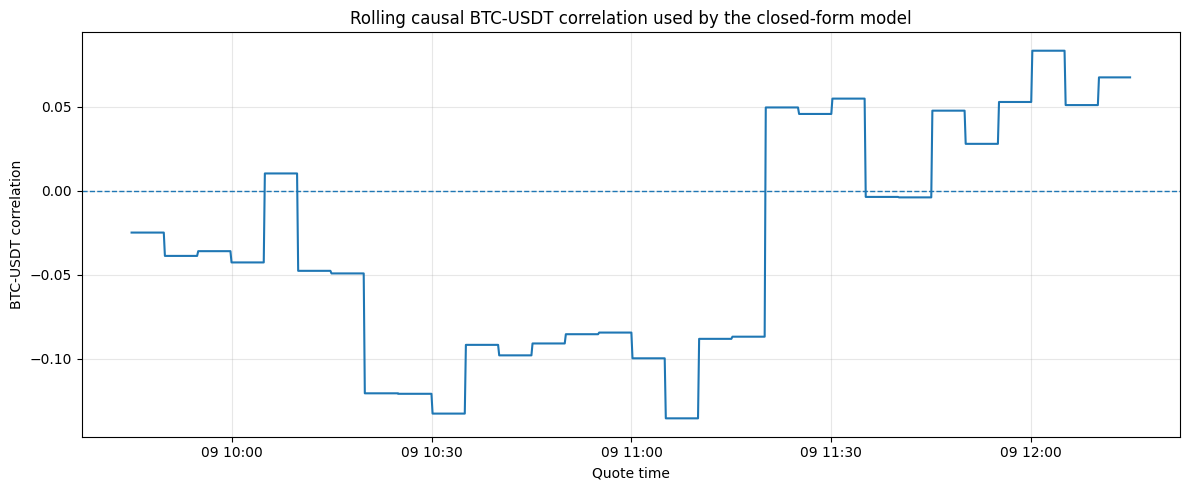

In [97]:
plt.figure(figsize=(12, 5))

plt.plot(
    walk_forward_quotes["trade_time"],
    walk_forward_quotes["rho"],
)

plt.axhline(
    0.0,
    linewidth=1.0,
    linestyle="--",
)

plt.xlabel("Quote time")
plt.ylabel("BTC-USDT correlation")
plt.title("Rolling causal BTC-USDT correlation used by the closed-form model")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Cell 19 — Match real trades to active quotes

Matches each BTC and USDT trade to the latest active generated quote in $[t_i,t_{i+1})$ and computes side-aware quote reach and distance.


In [98]:
def compare_asset_trades_to_quotes(
    asset: str,
    quotes: pd.DataFrame,
) -> pd.DataFrame:
    quote_columns = [
        "trade_time",
        "next_quote_time",
        f"{asset}_bid",
        f"{asset}_ask",
        f"{asset}_best_bid",
        f"{asset}_best_ask",
        f"{asset}_reference_price",
        f"{asset}_orderbook_mid",
        f"{asset}_delta_bid",
        f"{asset}_delta_ask",
    ]

    quote_data = (
        quotes[quote_columns]
        .rename(
            columns={
                "trade_time": "quote_time",
            }
        )
        .sort_values(
            "quote_time",
            kind="mergesort",
        )
    )

    asset_trades = (
        trades[asset]
        .sort_values(
            "trade_time",
            kind="mergesort",
        )
        .copy()
    )

    matched = pd.merge_asof(
        asset_trades,
        quote_data,
        left_on="trade_time",
        right_on="quote_time",
        direction="backward",
    )

    matched = matched.loc[
        matched["quote_time"].notna()
        & matched["next_quote_time"].notna()
        & (
            matched["trade_time"]
            < matched["next_quote_time"]
        )
    ].copy()

    matched["compared_quote_price"] = np.where(
        matched["direction"].eq("buy"),
        matched[f"{asset}_bid"],
        matched[f"{asset}_ask"],
    )

    matched["same_side_market_price"] = np.where(
        matched["direction"].eq("buy"),
        matched[f"{asset}_best_bid"],
        matched[f"{asset}_best_ask"],
    )

    matched["signed_reach_margin"] = np.where(
        matched["direction"].eq("buy"),
        matched["compared_quote_price"]
        - matched["price"],
        matched["price"]
        - matched["compared_quote_price"],
    )

    matched["price_eligible_fill"] = (
        matched["compared_quote_price"].notna()
        & (
            matched["signed_reach_margin"]
            >= 0
        )
    )

    matched["absolute_quote_distance"] = (
        matched["compared_quote_price"]
        - matched["price"]
    ).abs()

    matched["distance_ticks"] = (
        matched["absolute_quote_distance"]
        / TICK_SIZE[asset]
    )

    matched["distance_bps"] = (
        matched["absolute_quote_distance"]
        / matched["price"].abs()
        * 10_000.0
    )

    matched["quote_age_seconds"] = (
        matched["trade_time"]
        - matched["quote_time"]
    ).dt.total_seconds()

    matched["asset"] = asset

    return matched


trade_quote_comparison = {
    asset: compare_asset_trades_to_quotes(
        asset=asset,
        quotes=walk_forward_quotes,
    )
    for asset in ASSETS
}

for asset in ASSETS:
    trade_quote_comparison[asset].to_csv(
        f"closed_form_{asset.lower()}_trade_quote_comparison.csv",
        index=False,
    )

    print(
        asset,
        "matched trades:",
        len(trade_quote_comparison[asset]),
    )


BTC matched trades: 200
USDT matched trades: 835


## Cell 20 — Quote fit metrics

Computes separate BTC and USDT coverage, eligibility, MAE, RMSE, $R^2$, correlation, bps/tick errors, and side-specific execution-fit metrics.


In [99]:
def safe_price_r_squared(
    actual: pd.Series,
    predicted: pd.Series,
) -> float:
    valid = (
        np.isfinite(actual)
        & np.isfinite(predicted)
    )

    y = actual[valid].to_numpy(float)
    y_hat = predicted[valid].to_numpy(float)

    if len(y) < 2:
        return np.nan

    ss_res = float(
        np.sum(
            (y - y_hat) ** 2
        )
    )

    ss_tot = float(
        np.sum(
            (y - np.mean(y)) ** 2
        )
    )

    return (
        float(1.0 - ss_res / ss_tot)
        if ss_tot > EPS
        else np.nan
    )


quote_fit_rows = []
quote_fit_by_side_rows = []

for asset in ASSETS:
    comparison = trade_quote_comparison[asset].copy()

    valid = comparison.dropna(
        subset=[
            "price",
            "compared_quote_price",
        ]
    )

    if valid.empty:
        continue

    error = (
        valid["compared_quote_price"]
        - valid["price"]
    )

    quote_fit_rows.append(
        {
            "asset": asset,
            "matched_trade_count": int(len(valid)),
            "matched_trade_coverage": float(
                len(valid)
                / max(
                    len(trades[asset]),
                    1,
                )
            ),
            "price_eligible_trade_rate": float(
                valid["price_eligible_fill"].mean()
            ),
            "mae_price": float(
                np.mean(
                    np.abs(error)
                )
            ),
            "rmse_price": float(
                math.sqrt(
                    np.mean(
                        error ** 2
                    )
                )
            ),
            "median_distance_ticks": float(
                valid["distance_ticks"].median()
            ),
            "p90_distance_ticks": float(
                valid["distance_ticks"].quantile(0.90)
            ),
            "p95_distance_ticks": float(
                valid["distance_ticks"].quantile(0.95)
            ),
            "mean_distance_bps": float(
                valid["distance_bps"].mean()
            ),
            "quote_trade_R2": safe_price_r_squared(
                valid["price"],
                valid["compared_quote_price"],
            ),
            "pearson_correlation": float(
                valid["price"].corr(
                    valid["compared_quote_price"]
                )
            ),
            "mean_quote_age_seconds": float(
                valid["quote_age_seconds"].mean()
            ),
        }
    )

    for direction, label in [
        ("buy", "maker_bid"),
        ("sell", "maker_ask"),
    ]:
        side = valid.loc[
            valid["direction"].eq(direction)
        ]

        if side.empty:
            continue

        quote_fit_by_side_rows.append(
            {
                "asset": asset,
                "side": label,
                "trade_count": int(len(side)),
                "price_eligible_rate": float(
                    side["price_eligible_fill"].mean()
                ),
                "mae_price": float(
                    side["absolute_quote_distance"].mean()
                ),
                "median_distance_ticks": float(
                    side["distance_ticks"].median()
                ),
                "mean_distance_bps": float(
                    side["distance_bps"].mean()
                ),
            }
        )

quote_fit_summary = pd.DataFrame(
    quote_fit_rows
)

quote_fit_by_side = pd.DataFrame(
    quote_fit_by_side_rows
)

display(quote_fit_summary)
display(quote_fit_by_side)

quote_fit_summary.to_csv(
    "closed_form_quote_fit_summary.csv",
    index=False,
)

quote_fit_by_side.to_csv(
    "closed_form_quote_fit_by_side.csv",
    index=False,
)


,asset,matched_trade_count,matched_trade_coverage,price_eligible_trade_rate,mae_price,rmse_price,median_distance_ticks,p90_distance_ticks,p95_distance_ticks,mean_distance_bps,quote_trade_R2,pearson_correlation,mean_quote_age_seconds
0,BTC,194,0.009929,0.453608,5.094393e+06,8.023433e+06,3342845.0,11997223.1,12891057.6,4.608470,0.867044,0.932632,4.762887
1,USDT,750,0.005810,0.356000,5.307733e+01,7.766398e+01,39.0,126.1,178.1,3.014069,0.873225,0.938594,4.473333


,asset,side,trade_count,price_eligible_rate,mae_price,median_distance_ticks,mean_distance_bps
0,BTC,maker_bid,93,0.419355,4.849976e+06,3809258.0,4.392278
1,BTC,maker_ask,101,0.485149,5.319450e+06,3029000.0,4.807539
2,USDT,maker_bid,316,0.455696,6.279747e+01,39.0,3.567422
3,USDT,maker_ask,434,0.283410,4.600000e+01,39.0,2.611166


## Cell 21 — Plot BTC generated quotes, market prices, and executions

Reproduces the previous quote-quality chart for BTC using the multi-asset closed-form strategy.


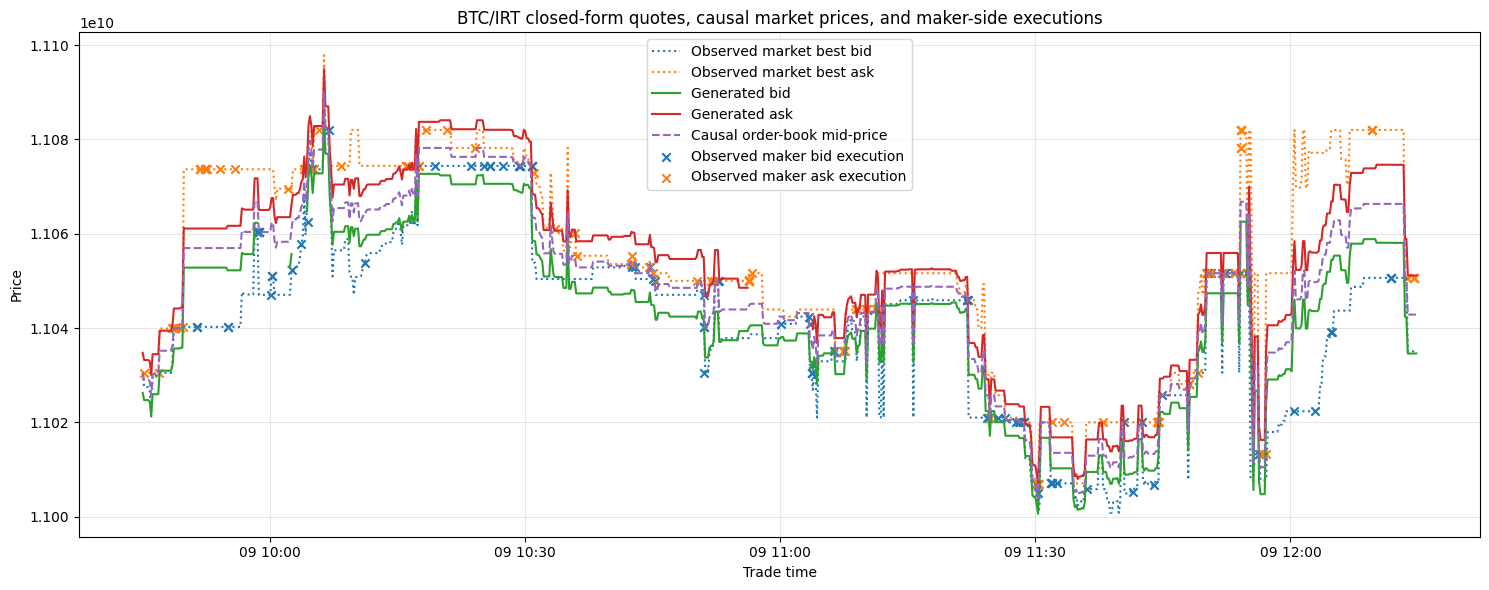

In [100]:
def plot_asset_quotes(
    asset: str,
    quotes: pd.DataFrame,
    comparison: pd.DataFrame,
):
    plt.figure(figsize=(15, 6))

    plt.plot(
        quotes["trade_time"],
        quotes[f"{asset}_best_bid"],
        linestyle=":",
        label="Observed market best bid",
    )

    plt.plot(
        quotes["trade_time"],
        quotes[f"{asset}_best_ask"],
        linestyle=":",
        label="Observed market best ask",
    )

    plt.plot(
        quotes["trade_time"],
        quotes[f"{asset}_bid"],
        label="Generated bid",
    )

    plt.plot(
        quotes["trade_time"],
        quotes[f"{asset}_ask"],
        label="Generated ask",
    )

    plt.plot(
        quotes["trade_time"],
        quotes[f"{asset}_orderbook_mid"],
        linestyle="--",
        label="Causal order-book mid-price",
    )

    maker_bid = comparison.loc[
        comparison["direction"].eq("buy")
    ]

    maker_ask = comparison.loc[
        comparison["direction"].eq("sell")
    ]

    plt.scatter(
        maker_bid["trade_time"],
        maker_bid["price"],
        marker="x",
        label="Observed maker bid execution",
    )

    plt.scatter(
        maker_ask["trade_time"],
        maker_ask["price"],
        marker="x",
        label="Observed maker ask execution",
    )

    plt.xlabel("Trade time")
    plt.ylabel("Price")
    plt.title(
        f"{asset}/IRT closed-form quotes, causal market prices, and maker-side executions"
    )
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_asset_quotes(
    asset="BTC",
    quotes=walk_forward_quotes,
    comparison=trade_quote_comparison["BTC"],
)


## Cell 22 — Plot USDT generated quotes, market prices, and executions

Reproduces the same quote-quality chart for USDT after converting the raw taker direction into the maker-side convention.


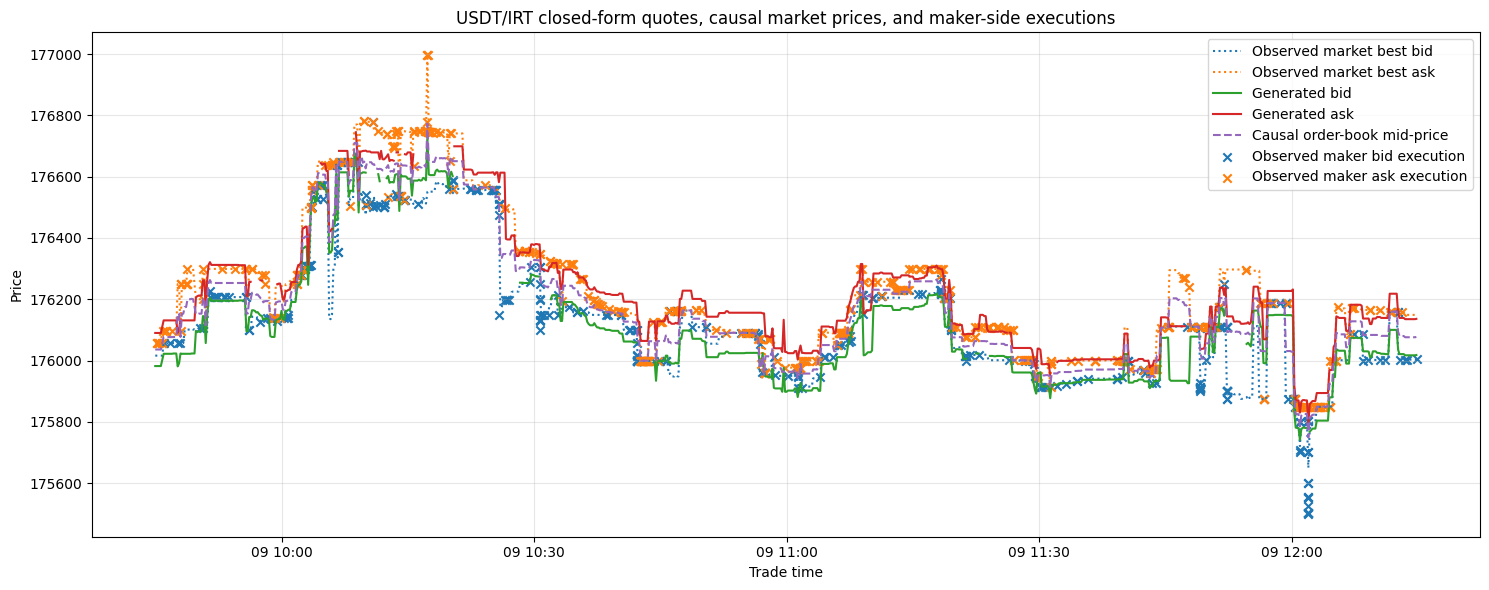

In [101]:
plot_asset_quotes(
    asset="USDT",
    quotes=walk_forward_quotes,
    comparison=trade_quote_comparison["USDT"],
)


## Cell 23 — Finite-horizon versus asymptotic quote comparison

Measures how far the finite-horizon approximation is from the asymptotic approximation for BTC and USDT.


,asset,mean_abs_bid_delta_difference,mean_abs_ask_delta_difference
0,BTC,299235.286854,322113.023502
1,USDT,1.922207,1.860684


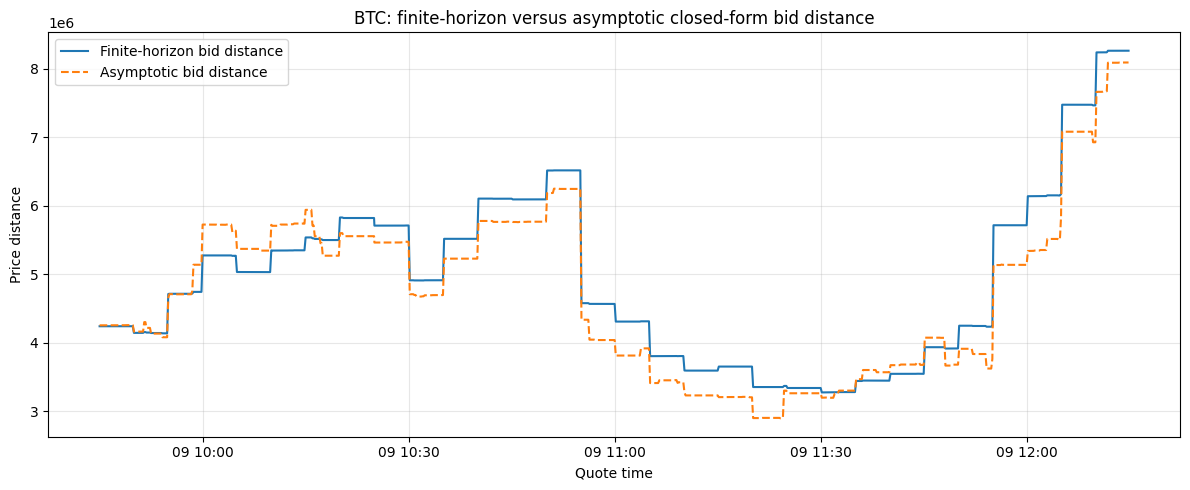

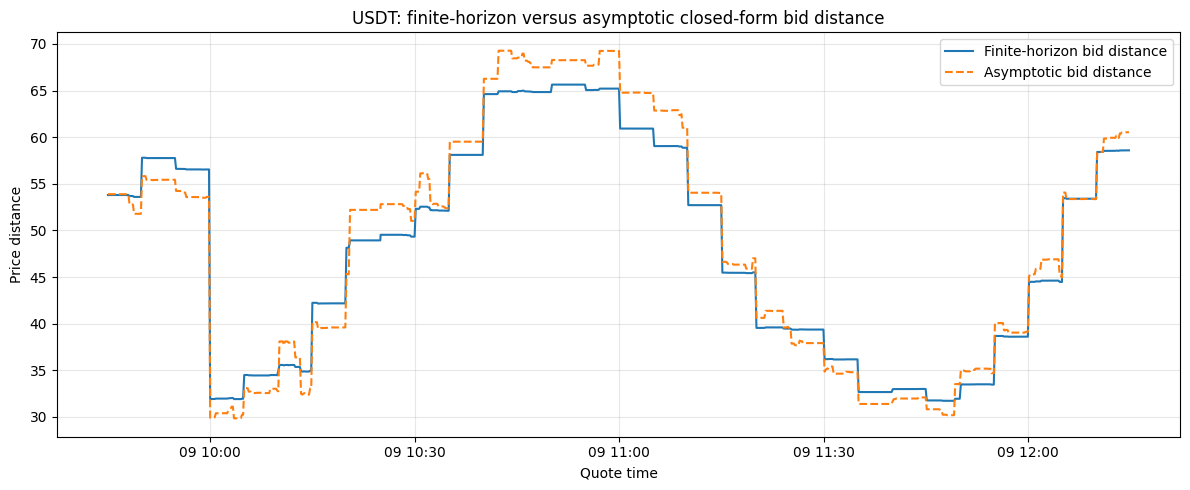

In [102]:
finite_asymptotic_rows = []

for asset in ASSETS:
    finite_asymptotic_rows.append(
        {
            "asset": asset,
            "mean_abs_bid_delta_difference": float(
                (
                    walk_forward_quotes[
                        f"{asset}_finite_delta_bid"
                    ]
                    - walk_forward_quotes[
                        f"{asset}_asym_delta_bid"
                    ]
                ).abs().mean()
            ),
            "mean_abs_ask_delta_difference": float(
                (
                    walk_forward_quotes[
                        f"{asset}_finite_delta_ask"
                    ]
                    - walk_forward_quotes[
                        f"{asset}_asym_delta_ask"
                    ]
                ).abs().mean()
            ),
        }
    )

finite_vs_asymptotic = pd.DataFrame(
    finite_asymptotic_rows
)

display(finite_vs_asymptotic)

for asset in ASSETS:
    plt.figure(figsize=(12, 5))

    plt.plot(
        walk_forward_quotes["trade_time"],
        walk_forward_quotes[f"{asset}_finite_delta_bid"],
        label="Finite-horizon bid distance",
    )

    plt.plot(
        walk_forward_quotes["trade_time"],
        walk_forward_quotes[f"{asset}_asym_delta_bid"],
        linestyle="--",
        label="Asymptotic bid distance",
    )

    plt.xlabel("Quote time")
    plt.ylabel("Price distance")
    plt.title(
        f"{asset}: finite-horizon versus asymptotic closed-form bid distance"
    )
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Cell 24 — Cross-asset coupling diagnostic

Compares the correlated multi-asset quote distances with an otherwise identical benchmark in which the off-diagonal covariance is set to zero.


,asset,mean_abs_bid_shift_due_to_correlation,mean_abs_ask_shift_due_to_correlation,mean_signed_bid_shift_due_to_correlation,mean_signed_ask_shift_due_to_correlation
0,BTC,1152.660898,1152.642917,-494.427691,494.395112
1,USDT,0.012355,0.012355,0.005429,-0.005429


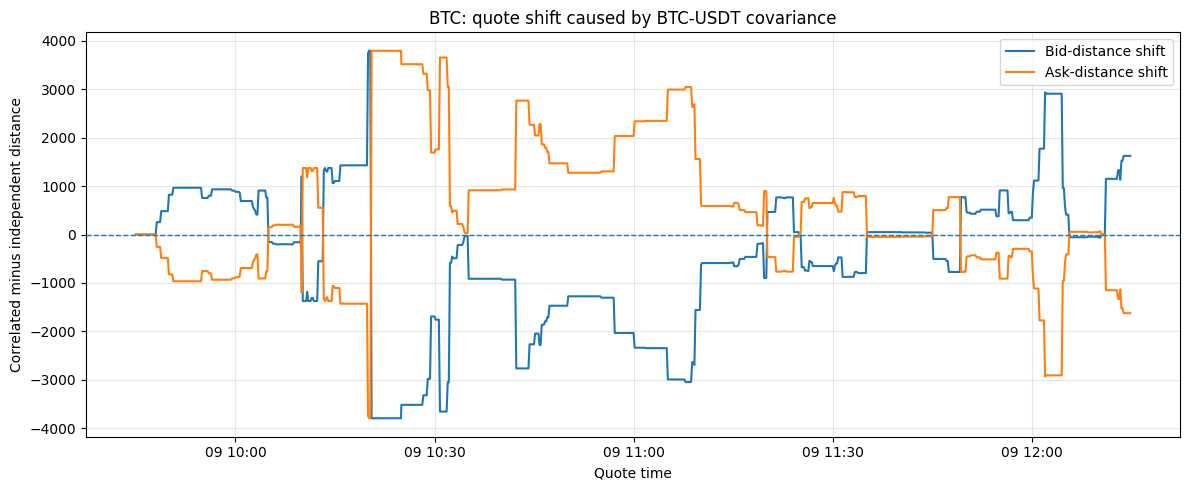

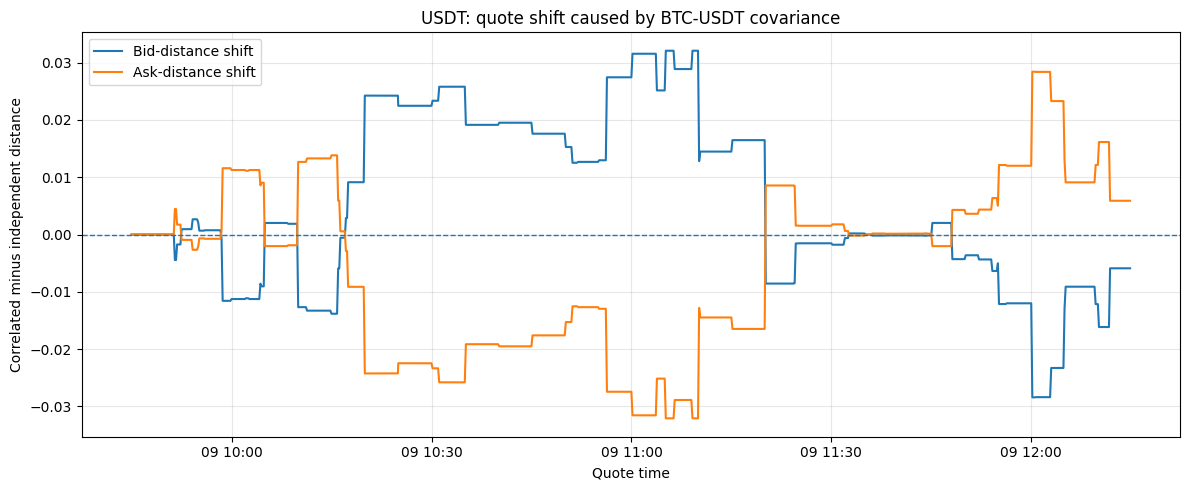

In [103]:
cross_asset_effect_rows = []

for asset in ASSETS:
    bid_effect = (
        walk_forward_quotes[
            f"{asset}_delta_bid"
        ]
        - walk_forward_quotes[
            f"{asset}_independent_delta_bid"
        ]
    )

    ask_effect = (
        walk_forward_quotes[
            f"{asset}_delta_ask"
        ]
        - walk_forward_quotes[
            f"{asset}_independent_delta_ask"
        ]
    )

    cross_asset_effect_rows.append(
        {
            "asset": asset,
            "mean_abs_bid_shift_due_to_correlation": float(
                bid_effect.abs().mean()
            ),
            "mean_abs_ask_shift_due_to_correlation": float(
                ask_effect.abs().mean()
            ),
            "mean_signed_bid_shift_due_to_correlation": float(
                bid_effect.mean()
            ),
            "mean_signed_ask_shift_due_to_correlation": float(
                ask_effect.mean()
            ),
        }
    )

cross_asset_effect_summary = pd.DataFrame(
    cross_asset_effect_rows
)

display(cross_asset_effect_summary)

for asset in ASSETS:
    plt.figure(figsize=(12, 5))

    plt.plot(
        walk_forward_quotes["trade_time"],
        (
            walk_forward_quotes[f"{asset}_delta_bid"]
            - walk_forward_quotes[
                f"{asset}_independent_delta_bid"
            ]
        ),
        label="Bid-distance shift",
    )

    plt.plot(
        walk_forward_quotes["trade_time"],
        (
            walk_forward_quotes[f"{asset}_delta_ask"]
            - walk_forward_quotes[
                f"{asset}_independent_delta_ask"
            ]
        ),
        label="Ask-distance shift",
    )

    plt.axhline(
        0.0,
        linewidth=1.0,
        linestyle="--",
    )

    plt.xlabel("Quote time")
    plt.ylabel("Correlated minus independent distance")
    plt.title(
        f"{asset}: quote shift caused by BTC-USDT covariance"
    )
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Cell 25 — Build generated-strategy and actual-trade P&L paths

Constructs separate BTC and USDT marked-to-market P&L, liquidation P&L, spread capture, inventory paths, and actual-trade replay benchmarks under the same inventory constraints.


In [104]:
def replay_actual_trades(
    asset: str,
    quotes: pd.DataFrame,
    Q_states: Dict[str, int],
) -> pd.DataFrame:
    capacity = inventory_capacity(
        asset,
        Q_states,
    )

    inventory = capacity / 2.0
    cash = 0.0

    asset_trades = trades[asset].sort_values(
        "trade_time",
        kind="mergesort",
    )

    trade_times = asset_trades["trade_time"].to_numpy(
        dtype="datetime64[ns]"
    )

    rows = []

    for _, quote in quotes.iterrows():
        quote_time = pd.Timestamp(
            quote["trade_time"]
        )

        next_quote_time = pd.Timestamp(
            quote["next_quote_time"]
        )

        left = int(
            np.searchsorted(
                trade_times,
                np.datetime64(quote_time),
                side="left",
            )
        )

        right = int(
            np.searchsorted(
                trade_times,
                np.datetime64(next_quote_time),
                side="left",
            )
        )

        interval = asset_trades.iloc[
            left:right
        ]

        inventory_before = inventory
        cash_before = cash
        executed_volume = 0.0
        spread_capture = 0.0
        executed_notional = 0.0

        reference = float(
            quote[f"{asset}_reference_price"]
        )

        for _, trade in interval.iterrows():
            volume = float(trade["volume"])
            price = float(trade["price"])

            if trade["direction"] == "buy":
                executable = min(
                    volume,
                    max(
                        capacity - inventory,
                        0.0,
                    ),
                )

                inventory += executable
                cash -= price * executable
                spread_capture += (
                    reference - price
                ) * executable

            else:
                executable = min(
                    volume,
                    max(inventory, 0.0),
                )

                inventory -= executable
                cash += price * executable
                spread_capture += (
                    price - reference
                ) * executable

            executed_volume += executable
            executed_notional += (
                price * executable
            )

        rows.append(
            {
                "trade_time": quote_time,
                "inventory_before": inventory_before,
                "inventory_after": inventory,
                "cash_before": cash_before,
                "cash_after": cash,
                "executed_volume": executed_volume,
                "executed_notional": executed_notional,
                "gross_spread_capture": spread_capture,
                "reference_price": reference,
                "marked_wealth": (
                    cash
                    + inventory
                    * reference
                ),
            }
        )

    return pd.DataFrame(rows)


pnl_paths = {}
actual_trade_benchmarks = {}
pnl_summary_rows = []

for asset in ASSETS:
    capacity = inventory_capacity(
        asset,
        Q_STATES,
    )

    initial_inventory = capacity / 2.0

    initial_reference = float(
        walk_forward_quotes[
            f"{asset}_reference_price"
        ].iloc[0]
    )

    initial_wealth = (
        initial_inventory
        * initial_reference
    )

    path = pd.DataFrame(
        {
            "trade_time": walk_forward_quotes["trade_time"],
            "reference_price": walk_forward_quotes[
                f"{asset}_reference_price"
            ],
            "best_bid": walk_forward_quotes[
                f"{asset}_best_bid"
            ],
            "inventory_before": walk_forward_quotes[
                f"{asset}_inventory_before"
            ],
            "inventory_after": walk_forward_quotes[
                f"{asset}_inventory_after"
            ],
            "cash_before": walk_forward_quotes[
                f"{asset}_cash_before"
            ],
            "cash_change": walk_forward_quotes[
                f"{asset}_cash_change"
            ],
            "cash_after": walk_forward_quotes[
                f"{asset}_cash_after"
            ],
            "bid_fill_volume": walk_forward_quotes[
                f"{asset}_bid_fill_volume"
            ],
            "ask_fill_volume": walk_forward_quotes[
                f"{asset}_ask_fill_volume"
            ],
            "bid": walk_forward_quotes[
                f"{asset}_bid"
            ],
            "ask": walk_forward_quotes[
                f"{asset}_ask"
            ],
        }
    )

    path["marked_wealth"] = (
        path["cash_after"]
        + path["inventory_after"]
        * path["reference_price"]
    )

    path["cumulative_mtm_pnl"] = (
        path["marked_wealth"]
        - initial_wealth
    )

    path["gross_spread_capture_step"] = (
        (
            path["reference_price"]
            - path["bid"]
        ).fillna(0.0)
        * path["bid_fill_volume"]
        +
        (
            path["ask"]
            - path["reference_price"]
        ).fillna(0.0)
        * path["ask_fill_volume"]
    )

    path["cumulative_gross_spread_capture"] = (
        path["gross_spread_capture_step"].cumsum()
    )

    running_max = path[
        "cumulative_mtm_pnl"
    ].cummax()

    path["drawdown"] = (
        running_max
        - path[
            "cumulative_mtm_pnl"
        ]
    )

    benchmark = replay_actual_trades(
        asset=asset,
        quotes=walk_forward_quotes,
        Q_states=Q_STATES,
    )

    benchmark["cumulative_mtm_pnl"] = (
        benchmark["marked_wealth"]
        - initial_wealth
    )

    benchmark[
        "cumulative_gross_spread_capture"
    ] = benchmark[
        "gross_spread_capture"
    ].cumsum()

    benchmark_running_max = benchmark[
        "cumulative_mtm_pnl"
    ].cummax()

    benchmark["drawdown"] = (
        benchmark_running_max
        - benchmark[
            "cumulative_mtm_pnl"
        ]
    )

    pnl_paths[asset] = path
    actual_trade_benchmarks[asset] = benchmark

    final_liquidation_wealth = (
        float(path["cash_after"].iloc[-1])
        + float(path["inventory_after"].iloc[-1])
        * float(path["best_bid"].iloc[-1])
    )

    benchmark_final_liquidation = (
        float(benchmark["cash_after"].iloc[-1])
        + float(benchmark["inventory_after"].iloc[-1])
        * float(path["best_bid"].iloc[-1])
    )

    pnl_summary_rows.append(
        {
            "asset": asset,
            "generated_final_mtm_pnl": float(
                path["cumulative_mtm_pnl"].iloc[-1]
            ),
            "actual_trade_replay_final_mtm_pnl": float(
                benchmark[
                    "cumulative_mtm_pnl"
                ].iloc[-1]
            ),
            "generated_final_liquidation_pnl": float(
                final_liquidation_wealth
                - initial_wealth
            ),
            "actual_trade_replay_final_liquidation_pnl": float(
                benchmark_final_liquidation
                - initial_wealth
            ),
            "generated_max_drawdown": float(
                path["drawdown"].max()
            ),
            "actual_trade_replay_max_drawdown": float(
                benchmark["drawdown"].max()
            ),
            "generated_gross_spread_capture": float(
                path[
                    "gross_spread_capture_step"
                ].sum()
            ),
            "actual_trade_replay_gross_spread_capture": float(
                benchmark[
                    "gross_spread_capture"
                ].sum()
            ),
            "generated_final_inventory": float(
                path["inventory_after"].iloc[-1]
            ),
            "actual_trade_replay_final_inventory": float(
                benchmark["inventory_after"].iloc[-1]
            ),
        }
    )

    path.to_csv(
        f"closed_form_{asset.lower()}_pnl_path.csv",
        index=False,
    )

    benchmark.to_csv(
        f"closed_form_{asset.lower()}_actual_trade_benchmark.csv",
        index=False,
    )

pnl_strategy_comparison = pd.DataFrame(
    pnl_summary_rows
)

display(pnl_strategy_comparison)

pnl_strategy_comparison.to_csv(
    "closed_form_pnl_strategy_comparison.csv",
    index=False,
)


,asset,generated_final_mtm_pnl,actual_trade_replay_final_mtm_pnl,generated_final_liquidation_pnl,actual_trade_replay_final_liquidation_pnl,generated_max_drawdown,actual_trade_replay_max_drawdown,generated_gross_spread_capture,actual_trade_replay_gross_spread_capture,generated_final_inventory,actual_trade_replay_final_inventory
0,BTC,431424.663728,144203.111506,383101.721683,144203.111506,417545.190356,1.049458e+06,299387.205788,1.071514e+06,0.00623,0.00
1,USDT,975.639698,162478.928964,-69349.756248,126329.888964,666459.408333,7.099346e+05,702889.895617,1.296974e+06,976.74161,502.07


## Cell 26 — BTC P&L and inventory plots

Plots the generated BTC strategy against the actual-trade replay and shows the corresponding inventory paths and boundaries.


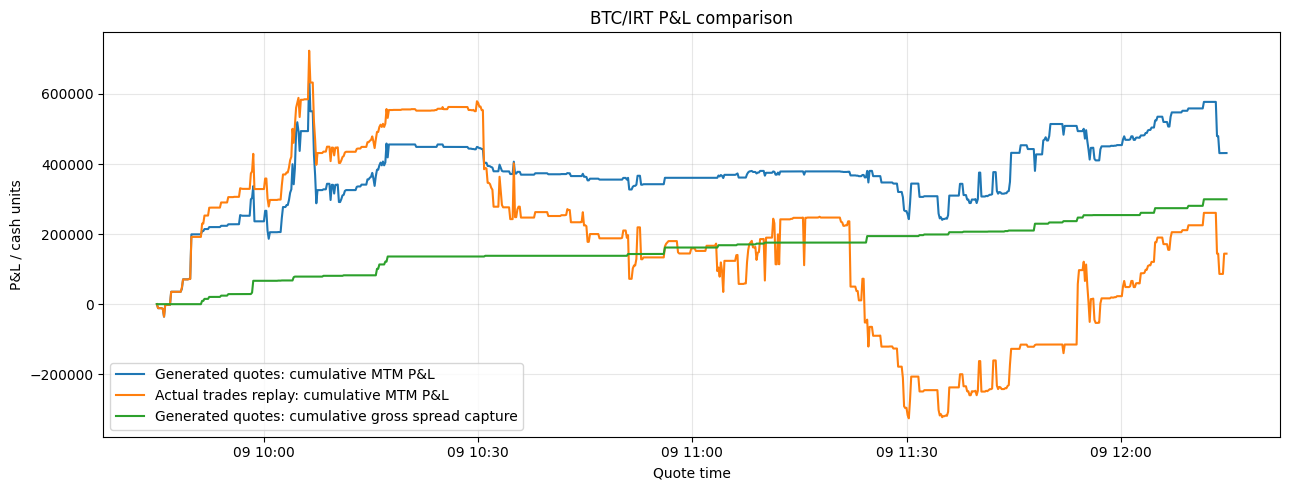

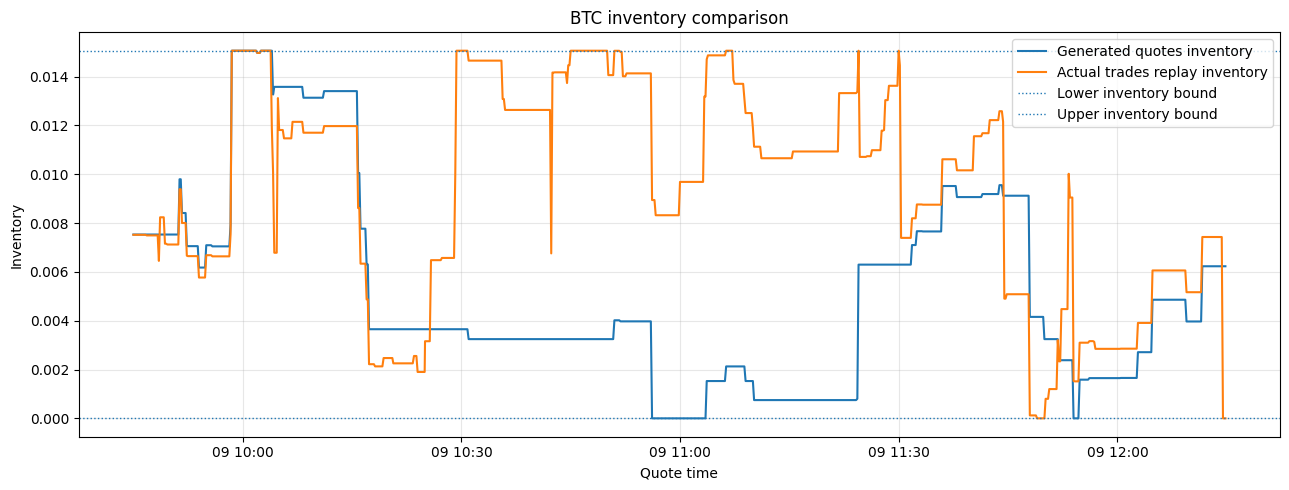

In [105]:
def plot_asset_pnl_and_inventory(
    asset: str,
    generated: pd.DataFrame,
    benchmark: pd.DataFrame,
    Q_states: Dict[str, int],
):
    plt.figure(figsize=(13, 5))

    plt.plot(
        generated["trade_time"],
        generated["cumulative_mtm_pnl"],
        label="Generated quotes: cumulative MTM P&L",
    )

    plt.plot(
        benchmark["trade_time"],
        benchmark["cumulative_mtm_pnl"],
        label="Actual trades replay: cumulative MTM P&L",
    )

    plt.plot(
        generated["trade_time"],
        generated["cumulative_gross_spread_capture"],
        label="Generated quotes: cumulative gross spread capture",
    )

    plt.xlabel("Quote time")
    plt.ylabel("P&L / cash units")
    plt.title(f"{asset}/IRT P&L comparison")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(13, 5))

    plt.plot(
        generated["trade_time"],
        generated["inventory_after"],
        label="Generated quotes inventory",
    )

    plt.plot(
        benchmark["trade_time"],
        benchmark["inventory_after"],
        label="Actual trades replay inventory",
    )

    plt.axhline(
        0.0,
        linewidth=1.0,
        linestyle=":",
        label="Lower inventory bound",
    )

    plt.axhline(
        inventory_capacity(
            asset,
            Q_states,
        ),
        linewidth=1.0,
        linestyle=":",
        label="Upper inventory bound",
    )

    plt.xlabel("Quote time")
    plt.ylabel("Inventory")
    plt.title(f"{asset} inventory comparison")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_asset_pnl_and_inventory(
    asset="BTC",
    generated=pnl_paths["BTC"],
    benchmark=actual_trade_benchmarks["BTC"],
    Q_states=Q_STATES,
)


## Cell 27 — USDT P&L and inventory plots

Plots the generated USDT strategy against the actual-trade replay and shows the corresponding inventory paths and boundaries.


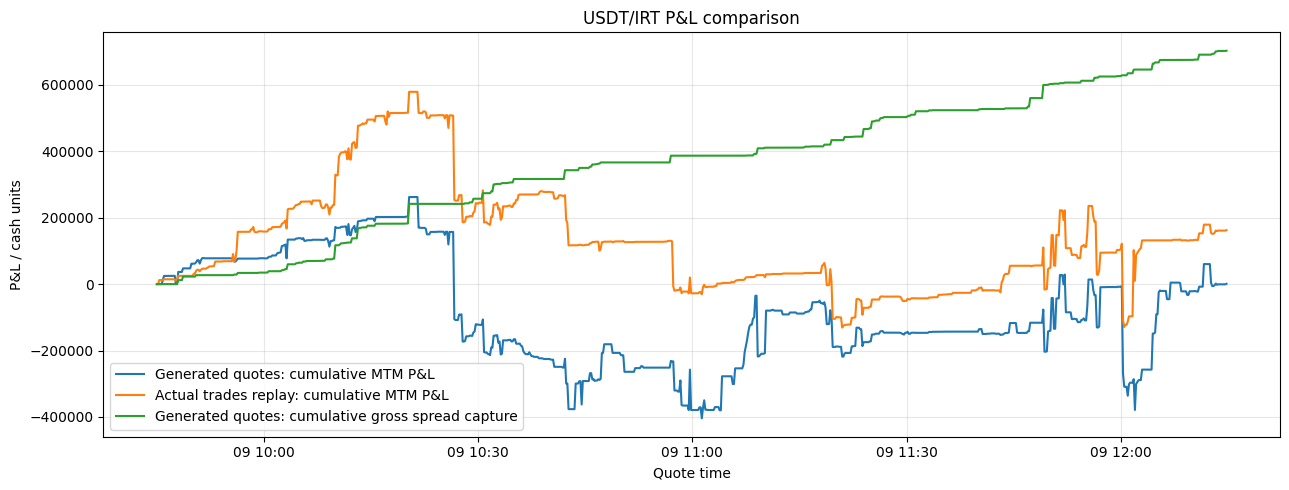

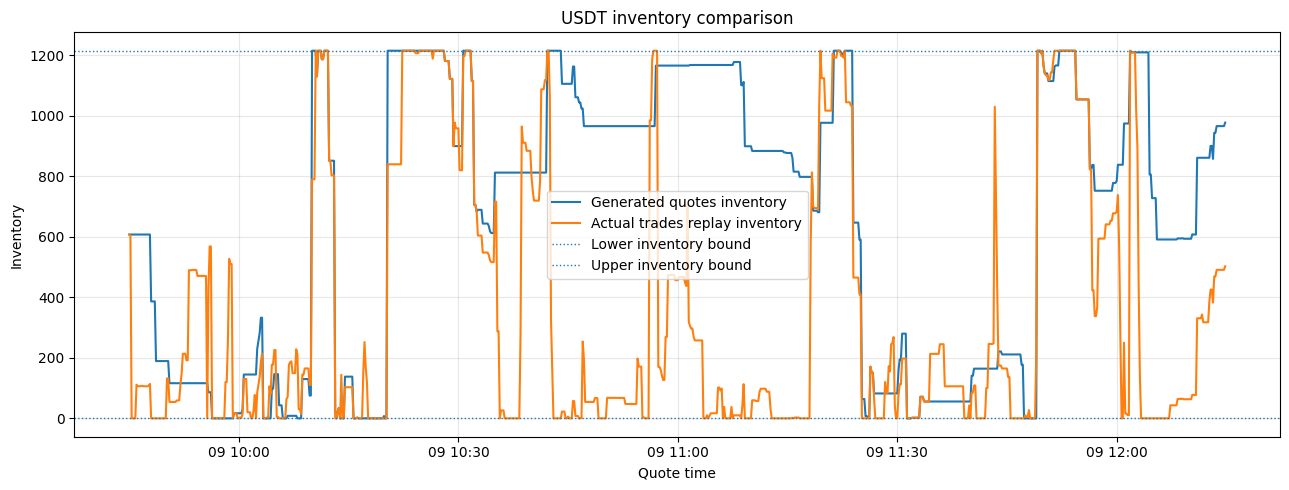

In [106]:
plot_asset_pnl_and_inventory(
    asset="USDT",
    generated=pnl_paths["USDT"],
    benchmark=actual_trade_benchmarks["USDT"],
    Q_states=Q_STATES,
)


## Cell 28 — Portfolio P&L

Aggregates BTC and USDT marked-to-market P&L into one portfolio-level comparison.


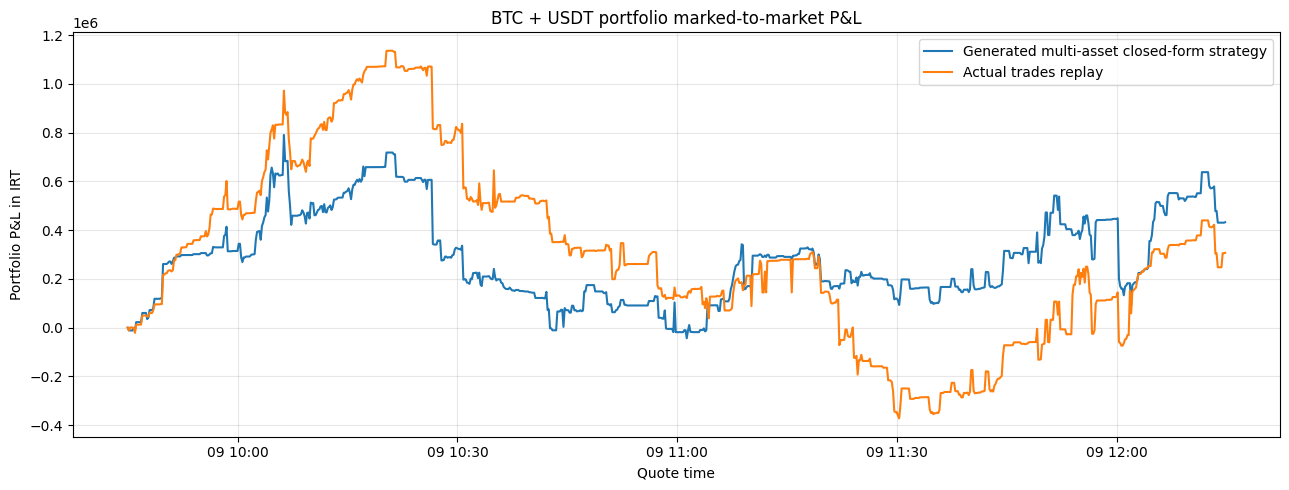

In [107]:
portfolio_pnl = pd.DataFrame(
    {
        "trade_time": walk_forward_quotes["trade_time"],
        "generated_portfolio_mtm_pnl": (
            pnl_paths["BTC"]["cumulative_mtm_pnl"].to_numpy(float)
            + pnl_paths["USDT"]["cumulative_mtm_pnl"].to_numpy(float)
        ),
        "actual_trade_replay_portfolio_mtm_pnl": (
            actual_trade_benchmarks["BTC"][
                "cumulative_mtm_pnl"
            ].to_numpy(float)
            + actual_trade_benchmarks["USDT"][
                "cumulative_mtm_pnl"
            ].to_numpy(float)
        ),
    }
)

plt.figure(figsize=(13, 5))

plt.plot(
    portfolio_pnl["trade_time"],
    portfolio_pnl[
        "generated_portfolio_mtm_pnl"
    ],
    label="Generated multi-asset closed-form strategy",
)

plt.plot(
    portfolio_pnl["trade_time"],
    portfolio_pnl[
        "actual_trade_replay_portfolio_mtm_pnl"
    ],
    label="Actual trades replay",
)

plt.xlabel("Quote time")
plt.ylabel("Portfolio P&L in IRT")
plt.title("BTC + USDT portfolio marked-to-market P&L")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

portfolio_pnl.to_csv(
    "closed_form_portfolio_pnl.csv",
    index=False,
)


## Cell 29 — Per-trade quote-distance plots

Reproduces the trade-distance diagnostic separately for BTC and USDT. Maker-bid distances are shown in blue and maker-ask distances in orange; the rolling median and upper distance quantile are retained.


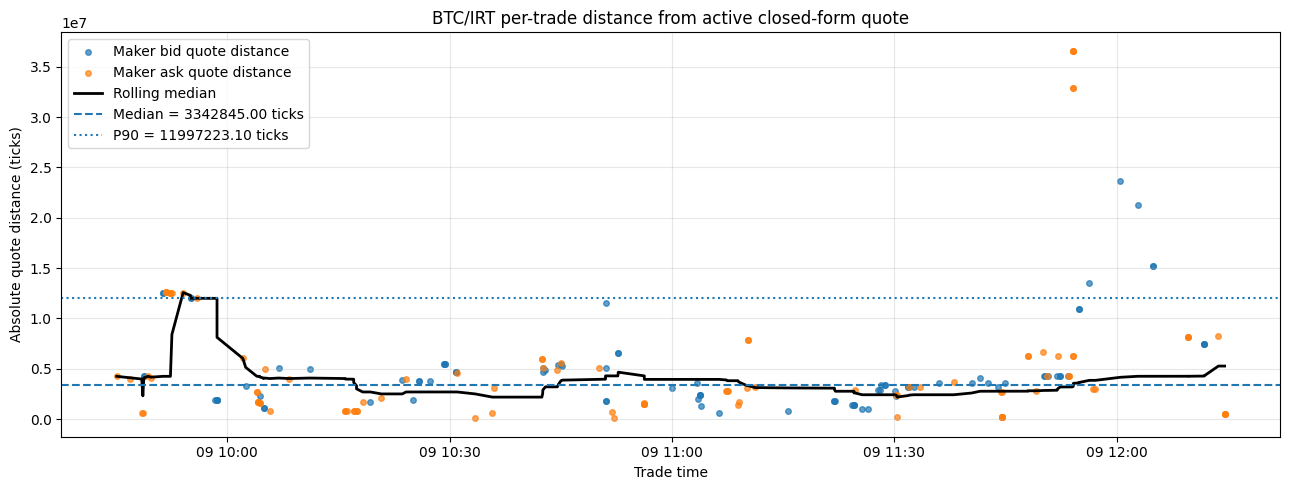

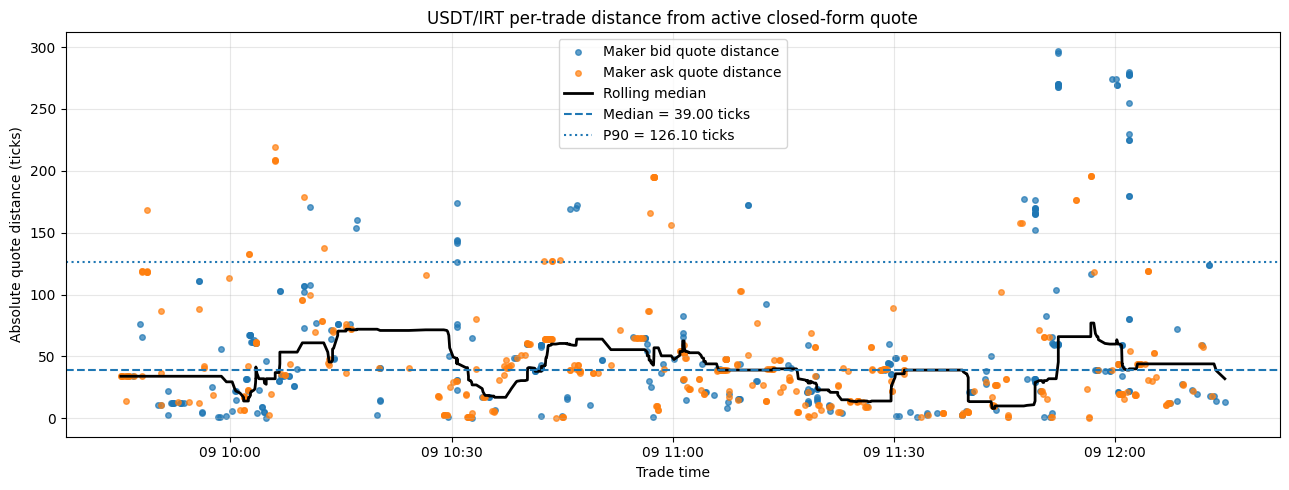

In [108]:
def plot_trade_distance(
    asset: str,
    comparison: pd.DataFrame,
):
    data = comparison.dropna(
        subset=[
            "trade_time",
            "distance_ticks",
        ]
    ).copy()

    if data.empty:
        print(asset, ": no valid trade-distance observations.")
        return

    data = data.sort_values(
        "trade_time",
        kind="mergesort",
    )

    rolling_median = (
        data["distance_ticks"]
        .rolling(
            window=max(
                5,
                min(
                    50,
                    len(data),
                ),
            ),
            min_periods=1,
        )
        .median()
    )

    median_distance = float(
        data["distance_ticks"].median()
    )

    p90_distance = float(
        data["distance_ticks"].quantile(0.90)
    )

    plt.figure(figsize=(13, 5))

    maker_bid = data.loc[
        data["direction"].eq("buy")
    ]

    maker_ask = data.loc[
        data["direction"].eq("sell")
    ]

    plt.scatter(
        maker_bid["trade_time"],
        maker_bid["distance_ticks"],
        s=16,
        alpha=0.7,
        color="tab:blue",
        label="Maker bid quote distance",
    )

    plt.scatter(
        maker_ask["trade_time"],
        maker_ask["distance_ticks"],
        s=16,
        alpha=0.7,
        color="tab:orange",
        label="Maker ask quote distance",
    )

    plt.plot(
        data["trade_time"],
        rolling_median,
        linewidth=2.0,
        color="black",
        label="Rolling median",
    )

    plt.axhline(
        median_distance,
        linestyle="--",
        label=f"Median = {median_distance:.2f} ticks",
    )

    plt.axhline(
        p90_distance,
        linestyle=":",
        label=f"P90 = {p90_distance:.2f} ticks",
    )

    plt.xlabel("Trade time")
    plt.ylabel("Absolute quote distance (ticks)")
    plt.title(
        f"{asset}/IRT per-trade distance from active closed-form quote"
    )
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


for asset in ASSETS:
    plot_trade_distance(
        asset=asset,
        comparison=trade_quote_comparison[asset],
    )


## Cell 30 — Thirty-second markout evaluation

Computes the post-fill 30-second reference-price markout separately for BTC and USDT.


In [109]:
markout_rows = []

for asset in ASSETS:
    comparison = trade_quote_comparison[asset].copy()

    future_book = (
        orderbooks[asset][
            [
                "timestamp",
                "mid",
            ]
        ]
        .rename(
            columns={
                "timestamp": "future_book_time",
                "mid": "future_mid",
            }
        )
        .sort_values(
            "future_book_time",
            kind="mergesort",
        )
    )

    targets = comparison[
        [
            "trade_time",
        ]
    ].copy()

    targets["markout_target_time"] = (
        targets["trade_time"]
        + pd.Timedelta(
            seconds=MARKOUT_HORIZON_SECONDS
        )
    )

    future = pd.merge_asof(
        targets.sort_values(
            "markout_target_time"
        ),
        future_book,
        left_on="markout_target_time",
        right_on="future_book_time",
        direction="forward",
        tolerance=pd.Timedelta(
            seconds=MAX_ALIGNMENT_GAP_SECONDS
            + MARKOUT_HORIZON_SECONDS
        ),
    )

    comparison = comparison.reset_index(drop=True)
    future = future.reset_index(drop=True)

    comparison["future_mid"] = future["future_mid"]

    comparison["markout_30s"] = np.where(
        comparison["direction"].eq("buy"),
        comparison["future_mid"]
        - comparison["compared_quote_price"],
        comparison["compared_quote_price"]
        - comparison["future_mid"],
    )

    eligible = comparison.loc[
        comparison["price_eligible_fill"]
        & np.isfinite(
            comparison["markout_30s"]
        )
    ]

    markout_rows.append(
        {
            "asset": asset,
            "eligible_markout_count": int(len(eligible)),
            "mean_30s_markout": float(
                eligible["markout_30s"].mean()
            )
            if not eligible.empty
            else np.nan,
            "positive_30s_markout_rate": float(
                (
                    eligible["markout_30s"]
                    > 0
                ).mean()
            )
            if not eligible.empty
            else np.nan,
        }
    )

    trade_quote_comparison[asset] = comparison

markout_summary = pd.DataFrame(
    markout_rows
)

display(markout_summary)

markout_summary.to_csv(
    "closed_form_markout_summary.csv",
    index=False,
)


,asset,eligible_markout_count,mean_30s_markout,positive_30s_markout_rate
0,BTC,88,-1.008690e+06,0.602273
1,USDT,267,1.119101e+01,0.629213


## Cell 31 — Final comparison tables

Combines the main parameter, quote-fit, P&L, markout, finite-versus-asymptotic, and cross-asset-correlation results into compact final outputs.


In [110]:
final_comparison = (
    quote_fit_summary
    .merge(
        pnl_strategy_comparison,
        on="asset",
        how="outer",
    )
    .merge(
        markout_summary,
        on="asset",
        how="outer",
    )
    .merge(
        finite_vs_asymptotic,
        on="asset",
        how="outer",
    )
    .merge(
        cross_asset_effect_summary,
        on="asset",
        how="outer",
    )
    .merge(
        closed_form_parameter_summary,
        on="asset",
        how="outer",
    )
)

display(final_comparison.T)

final_comparison.to_csv(
    "closed_form_final_comparison.csv",
    index=False,
)

print("Saved outputs:")
print("  closed_form_multi_asset_walk_forward.csv")
print("  closed_form_parameter_summary.csv")
print("  closed_form_quote_fit_summary.csv")
print("  closed_form_quote_fit_by_side.csv")
print("  closed_form_pnl_strategy_comparison.csv")
print("  closed_form_portfolio_pnl.csv")
print("  closed_form_markout_summary.csv")
print("  closed_form_final_comparison.csv")


,0,1
asset,BTC,USDT
matched_trade_count,194,750
matched_trade_coverage,0.009929,0.00581
price_eligible_trade_rate,0.453608,0.356
mae_price,5094392.675258,53.077333
rmse_price,8023433.023371,77.663977
median_distance_ticks,3342845.0,39.0
p90_distance_ticks,11997223.1,126.1
p95_distance_ticks,12891057.6,178.1
mean_distance_bps,4.60847,3.014069


Saved outputs:
  closed_form_multi_asset_walk_forward.csv
  closed_form_parameter_summary.csv
  closed_form_quote_fit_summary.csv
  closed_form_quote_fit_by_side.csv
  closed_form_pnl_strategy_comparison.csv
  closed_form_portfolio_pnl.csv
  closed_form_markout_summary.csv
  closed_form_final_comparison.csv
